### Notebook 2: Partitioning Methods

### Grouping Online Retail Customers with K-Means, K-Modes and Related Methods

In Notebook 1, we prepared the Online Retail customer data.

Now we start clustering.

The main idea is simple:

**We want to group similar customers together.**

- Some customers buy often.
- Some customers spend a lot.
- Some customers have not bought for a long time.
- Some customers are rare but very valuable.

Clustering helps us find these groups without already having labels.

---

#### Topics covered in this notebook

#### 1. Loading the prepared customer data

We load the customer-level RFM data created in Notebook 1.

#### 2. Creating a simple customer map

We use PCA only for visualisation, so we can see customers in a 2D chart.

##### 3. K-Means clustering

We test K-Means with `k = 3`, `k = 5`, and `k = 7`.

##### 4. Elbow method

We check how many clusters may be reasonable.

##### 5. K-Means business profiles

We study each cluster using Recency, Frequency and Monetary values.

##### 6. MiniBatchKMeans

We test a faster version of K-Means and compare the result.

##### 7. K-Modes

We group customers using categorical features such as country, product pattern and RFM groups.

##### 8. K-Medoids / medoid-style fallback

We test a more outlier-aware method that uses real customer representatives.

##### 9. K-Prototypes

We combine numerical RFM values and categorical customer features.

##### 10. Outlier sensitivity check

We check whether extreme VIP or unusual customers affect the partitioning result.

##### 11. Method comparison

We compare methods using Silhouette, Davies-Bouldin and Calinski-Harabasz scores.

##### 12. Final recommendation

We decide which method should be carried forward as the main partitioning baseline.

---

##### Main output of this notebook

By the end, we will know which partitioning method gives the clearest and most useful customer groups.

From the executed results, the main recommendation is:

**Use K-Means with k=5 as the main partitioning baseline.**

K-Modes is also useful because it finds category-based high-value customer patterns.


### 1. Why partitioning methods matter

Partitioning methods answer this business question:

> Can we divide Online Retail customers into useful customer groups?

Examples of possible groups:

| Customer type | Behaviour pattern |
|---|---|
| Loyal high-value customers | recent, frequent, high spend |
| Inactive low-value customers | old purchase, low frequency, low spend |
| Frequent small buyers | frequent purchases, lower spend |
| One-time bulk buyers | low frequency, high spend |

Different methods use different information.

- K-Means uses numerical behaviour.  
- K-Modes uses categorical behaviour.  
- K-Prototypes combines both.

### 2. Load prepared outputs from Notebook 1

### Why this step is done

Notebook 2 should not repeat data cleaning.

Notebook 1 already prepared the customer-level data. 
Here we load those outputs and check that they are available.

### Inputs used

| Input file | Used for |
|---|---|
| `rfm_customer_table.csv` | Customer profile and business interpretation |
| `rfm_scaled.csv` | Numerical clustering |
| `customer_categorical_features.csv` | K-Modes and K-Prototypes |

### Output created

This step creates three DataFrames:

| DataFrame | Meaning |
|---|---|
| `rfm` | Original customer-level RFM table |
| `rfm_scaled` | Scaled numerical features |
| `customer_categories` | Categorical customer features |

In [37]:
# -----------------------------
# Import required libraries
# -----------------------------
# pathlib is used for relative project folders.
# pandas and numpy are used for data handling.
# matplotlib is used for charts.
# sklearn is used for clustering, PCA, encoding and metrics.

from pathlib import Path
import sys
import subprocess
import importlib
import warnings
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import OrdinalEncoder

warnings.filterwarnings("ignore")

# Relative folders only.
# These folders should already exist from Notebook 1, but we create them again safely.
OUTPUT_DIR = Path("outputs")
REPORT_DIR = Path("reports")

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("Libraries loaded.")
print("Python version:", sys.version.split()[0])

Libraries loaded.
Python version: 3.10.9


In [38]:
# -----------------------------
# Load prepared files from Notebook 1
# -----------------------------

# rfm:
#   One row per customer with original Recency, Frequency and Monetary values.
#
# rfm_scaled:
#   Scaled RFM values created with StandardScaler.
#   These are used by numerical distance-based methods.
#
# customer_categories:

#   Categorical customer-level features.
#   These are used by K-Modes and K-Prototypes.

required_files = {
    "rfm": OUTPUT_DIR / "rfm_customer_table.csv",
    "rfm_scaled": OUTPUT_DIR / "rfm_scaled.csv",
    "customer_categories": OUTPUT_DIR / "customer_categorical_features.csv",
}

missing_files = [str(path) for path in required_files.values() if not path.exists()]

if missing_files:
    raise FileNotFoundError(
        "Notebook 2 cannot start because these files are missing:\n"
        + "\n".join(missing_files)
        + "\n\nRun Notebook 1 first and make sure it saves the required outputs."
    )

rfm = pd.read_csv(required_files["rfm"])
rfm_scaled = pd.read_csv(required_files["rfm_scaled"])
customer_categories = pd.read_csv(required_files["customer_categories"])

print("Prepared files loaded successfully.")
print("RFM shape:", rfm.shape)
print("Scaled RFM shape:", rfm_scaled.shape)
print("Categorical features shape:", customer_categories.shape)

display(rfm.head())
display(rfm_scaled.head())
display(customer_categories.head())

Prepared files loaded successfully.
RFM shape: (4312, 9)
Scaled RFM shape: (4312, 4)
Categorical features shape: (4312, 6)


,CustomerID,LastPurchaseDate,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,Country,DominantProduct
0,12346,2010-06-28 13:53:00,165,11,372.86,70,26,United Kingdom,DOORMAT 3 SMILEY CATS
1,12347,2010-12-07 14:57:00,3,2,1323.32,828,70,Iceland,3D DOG PICTURE PLAYING CARDS
2,12348,2010-09-27 14:59:00,74,1,222.16,373,20,Finland,36 DOILIES VINTAGE CHRISTMAS
3,12349,2010-10-28 08:23:00,43,3,2671.14,993,90,Italy,LOVE HEART SOCK HANGER
4,12351,2010-11-29 15:23:00,11,1,300.93,261,21,Unspecified,BLUE SCANDINAVIAN PAISLEY WRAP


,CustomerID,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,12346,0.762299,0.801087,-0.187139
1,12347,-0.910402,-0.300603,-0.080475
2,12348,-0.177305,-0.423013,-0.204052
3,12349,-0.497389,-0.178193,0.070784
4,12351,-0.827799,-0.423013,-0.195212


,CustomerID,Country,DominantProduct,RecencyGroup,FrequencyGroup,MonetaryGroup
0,12346,United Kingdom,DOORMAT 3 SMILEY CATS,Inactive,High Frequency,Low Monetary
1,12347,Iceland,3D DOG PICTURE PLAYING CARDS,Recent,Low Frequency,High Monetary
2,12348,Finland,36 DOILIES VINTAGE CHRISTMAS,Warm,Low Frequency,Low Monetary
3,12349,Italy,LOVE HEART SOCK HANGER,Warm,Medium Frequency,High Monetary
4,12351,Unspecified,BLUE SCANDINAVIAN PAISLEY WRAP,Recent,Low Frequency,Low Monetary


#### Explanation after loading the prepared data

The three loaded tables represent the same customer base in different forms.

| Table | What it tells us |
|---|---|
| `rfm` | Business-friendly customer behaviour in original values |
| `rfm_scaled` | Fair numerical input for distance-based clustering |
| `customer_categories` | Category patterns for K-Modes and K-Prototypes |

Your executed output shows:

- **4,312 customers**
- RFM shape: **(4312, 9)**
- Scaled RFM shape: **(4312, 4)**
- Categorical features shape: **(4312, 6)**

This confirms Notebook 1 created the correct base data for Notebook 2.

### 3. Create a 2D PCA view for visualisation

### Why this step is done

RFM has three numerical features:

- Recency
- Frequency
- Monetary

Cluster charts are easier to read in two dimensions.

PCA creates a 2D view that preserves as much numerical structure as possible.

### Important note

PCA is used here only for **visualisation**.  
The clustering models still use the proper scaled features.

In [39]:
# -----------------------------
# Prepare numerical clustering matrix
# -----------------------------
# X_scaled contains only the scaled RFM feature columns.
# This is the input for K-Means, MiniBatchKMeans, K-Medoids and fallback methods.

scaled_feature_columns = ["Recency_Scaled", "Frequency_Scaled", "Monetary_Scaled"]

X_scaled = rfm_scaled[scaled_feature_columns].copy()

# -----------------------------
# Create 2D PCA view for charts

# -----------------------------
# pca_2d transforms the 3 scaled RFM features into two visual components.
# pca_view stores CustomerID + PC1 + PC2 for plotting.

pca = PCA(n_components=2, random_state=42)
pca_values = pca.fit_transform(X_scaled)

pca_view = pd.DataFrame({
    "CustomerID": rfm_scaled["CustomerID"],
    "PC1": pca_values[:, 0],
    "PC2": pca_values[:, 1],
})

explained_variance = pca.explained_variance_ratio_.sum()

print("PCA 2D view created.")
print(f"Variance explained by PC1 + PC2: {explained_variance:.2%}")

pca_view.head()

PCA 2D view created.
Variance explained by PC1 + PC2: 88.96%


,CustomerID,PC1,PC2
0,12346,0.171102,0.752213
1,12347,0.045012,-0.915082
2,12348,-0.362528,-0.289656
3,12349,0.089845,-0.462995
4,12351,-0.140669,-0.892921


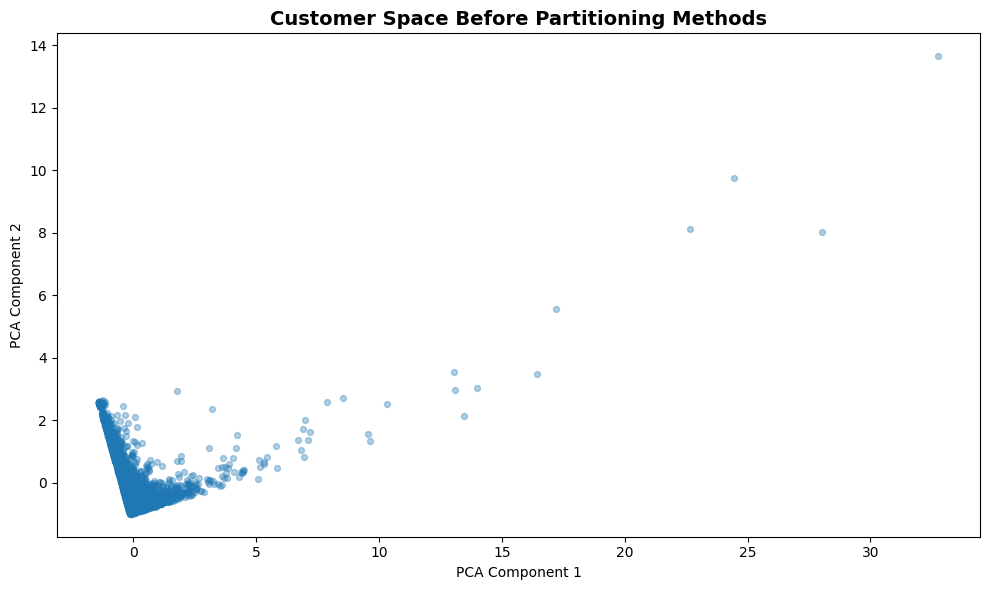

In [40]:
# Chart 1: PCA view before clustering.
# Purpose:
# Show the customer space before cluster labels are applied.

plt.figure(figsize=(10, 6))
plt.scatter(pca_view["PC1"], pca_view["PC2"], alpha=0.35, s=18)
plt.title("Customer Space Before Partitioning Methods", fontsize=14, weight="bold")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.tight_layout()
plt.show()

### Explanation after the PCA chart

The PCA chart is a visual map of customers.

Your executed output shows:

> **PC1 + PC2 explain 88.96% of the scaled RFM structure.**

That is strong enough to use the 2D PCA chart as a useful visual summary.

How to read the chart:

- Dense areas show common customer behaviour.
- Sparse areas show unusual or extreme customers.
- Points close together have similar Recency, Frequency and Monetary behaviour.
- The chart itself does not create clusters. It only helps us see the cluster labels later.

#### 4. Small helper functions

Before we run clustering models, we create a few small helper functions.

These functions are not the main topic.

They only help us avoid repeating the same code many times.

We will create:

1. one function to calculate clustering scores,
2. one function to summarize clusters,
3. one function to draw customer cluster charts,
4. one function to draw cluster profile charts.

In [41]:
# This function calculates the three clustering scores we use in this notebook.

# Input:
# - X: the scaled customer data used for clustering
# - cluster_labels: the cluster number assigned to each customer
#
# Output:
# - Silhouette score
# - Davies-Bouldin score
# - Calinski-Harabasz score

def calculate_clustering_scores(X, cluster_labels):
    
    # Convert labels into a numpy array.
    # This makes them easier for sklearn metric functions to use.
    
    cluster_labels = np.array(cluster_labels)
    
    # Count how many different clusters were created.
    
    number_of_clusters = len(np.unique(cluster_labels))
    
    # These scores need at least 2 clusters.
    # If there is only 1 cluster, the scores do not make sense.
    
    if number_of_clusters < 2:
        return {
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan
        }
    
    # If every customer becomes its own cluster, the scores also do not help.
    
    if number_of_clusters >= len(cluster_labels):
        return {
            "Silhouette": np.nan,
            "Davies_Bouldin": np.nan,
            "Calinski_Harabasz": np.nan
        }
    
    # Calculate the three clustering scores.
    
    scores = {
        "Silhouette": silhouette_score(X, cluster_labels),
        "Davies_Bouldin": davies_bouldin_score(X, cluster_labels),
        "Calinski_Harabasz": calinski_harabasz_score(X, cluster_labels)
    }
    
    return scores

## What this function does

Before we trust any clustering model, we need to check one thing:

**Did the model create useful customer groups?**

A clustering model gives us labels like this:

```text
Customer 1 → Cluster 0
Customer 2 → Cluster 1
Customer 3 → Cluster 0
Customer 4 → Cluster 2
```

But these labels alone do not tell us if the grouping is good.

The function `calculate_clustering_scores()` works like a **quality checker**.

It looks at the cluster labels and calculates three scores that help us compare different clustering methods.

---

## Why do we need this function?

In this notebook, we test several clustering methods:

* K-Means
* MiniBatchKMeans
* K-Medoids
* K-Prototypes

Each method creates cluster labels.

Instead of writing the scoring code again and again, we write one reusable function.

So the workflow becomes simple:

```text
Model creates clusters
        ↓
Function checks the clusters
        ↓
Function returns quality scores
        ↓
We compare the methods
```

This keeps the notebook cleaner and easier to follow.

---

## What goes into the function?

```python
calculate_clustering_scores(X, cluster_labels)
```

| Input            | Meaning                                                        |
| ---------------- | -------------------------------------------------------------- |
| `X`              | The customer data used for clustering, usually scaled RFM data |
| `cluster_labels` | The cluster number assigned to each customer                   |

Example:

```text
X = customer behaviour data

cluster_labels = [0, 1, 0, 2, 1, 2]
```

This means:

* some customers are in Cluster 0,
* some customers are in Cluster 1,
* some customers are in Cluster 2.

---

## Why does the function check the number of clusters first?

Some clustering results cannot be scored properly.

### Bad case 1: only one cluster

```text
All customers → Cluster 0
```

This is not useful.

The model did not really group customers.
It just put everyone into one basket.

So scores like Silhouette do not make sense.

---

### Bad case 2: every customer becomes a separate cluster

```text
Customer 1 → Cluster 0
Customer 2 → Cluster 1
Customer 3 → Cluster 2
Customer 4 → Cluster 3
```

This is also not useful.

The model did not create customer groups.
It simply separated everyone.

So the function returns `NaN`.

`NaN` means:

```text
This score cannot be calculated properly.
```

---

## The three scores returned by the function

### 1. Silhouette Score

Silhouette asks:

**Is each customer closer to its own cluster than to other clusters?**

Good clustering looks like this:

```text
Cluster A        Cluster B
● ● ●            ▲ ▲ ▲
● ● ●            ▲ ▲ ▲
```

Bad clustering looks like this:

```text
Mixed customers
● ▲ ● ▲ ● ▲
```

For Silhouette:

```text
Higher is better
```

A higher Silhouette score means the customer groups are more clearly separated.

---

### 2. Davies-Bouldin Score

Davies-Bouldin asks:

**Are the clusters compact and well separated?**

Good clustering:

```text
●●●          ▲▲▲          ■■■
```

Bad clustering:

```text
● ▲ ■ ● ▲ ■ ● ▲ ■
```

For Davies-Bouldin:

```text
Lower is better
```

A lower Davies-Bouldin score means the clusters are cleaner and less mixed.

---

### 3. Calinski-Harabasz Score

Calinski-Harabasz asks:

**Are customers inside each cluster close together, while different clusters are far apart?**

Simple idea:

```text
Good clustering =
customers inside one cluster are close
+
different clusters are far from each other
```

For Calinski-Harabasz:

```text
Higher is better
```

A higher score means the overall cluster structure is stronger.

---

## How we use this function in the notebook

For each clustering method, we do this:

```text
Run the model
        ↓
Get cluster labels
        ↓
Send labels to this function
        ↓
Get three scores
        ↓
Compare the methods
```

This helps us answer:

**Which clustering method created the clearest customer groups?**

---

## Simple memory trick

| Score             | Simple question                          | Good direction   |
| ----------------- | ---------------------------------------- | ---------------- |
| Silhouette        | Are customers close to their own group?  | Higher is better |
| Davies-Bouldin    | Are clusters messy or clean?             | Lower is better  |
| Calinski-Harabasz | Is the overall cluster structure strong? | Higher is better |

---

In [42]:
# This function explains each cluster in business terms.

# Input:
# - customer_table: the original RFM customer table
# - cluster_labels: cluster number assigned by a model
# - method_name: name of the clustering method
#
# Output:
# - one summary table showing average Recency, Frequency and Monetary per cluster

def create_cluster_summary(customer_table, cluster_labels, method_name):
    
    # Keep only the customer columns needed for interpretation.
    cluster_summary_data = customer_table[
        ["CustomerID", "Recency", "Frequency", "Monetary"]
    ].copy()
    
    # Add the cluster labels to each customer.
    cluster_summary_data["Cluster"] = cluster_labels
    
    # Group customers by cluster and calculate useful business values.
    cluster_summary = (
        cluster_summary_data
        .groupby("Cluster")
        .agg(
            Customers=("CustomerID", "count"),
            Avg_Recency=("Recency", "mean"),
            Avg_Frequency=("Frequency", "mean"),
            Avg_Monetary=("Monetary", "mean"),
            Total_Monetary=("Monetary", "sum")
        )
        .reset_index()
    )
    
    # Add method name so we know which model created the summary.
    cluster_summary["Method"] = method_name
    
    # Calculate customer share.
    cluster_summary["Customer_Share_%"] = (
        cluster_summary["Customers"] / len(cluster_summary_data) * 100
    )
    
    # Calculate revenue share.
    cluster_summary["Revenue_Share_%"] = (
        cluster_summary["Total_Monetary"] / cluster_summary["Total_Monetary"].sum() * 100
    )
    
    # Round values for cleaner display.
    cluster_summary = cluster_summary.round(2)
    
    return cluster_summary

## What this function does

After clustering, the model only gives numbers like:

`Cluster 0`, `Cluster 1`, `Cluster 2`

That is not useful for business.

This function turns those cluster numbers into a readable summary table.

It tells us:

- how many customers are in each cluster,
- how recently they bought,
- how often they bought,
- how much they spent,
- how much revenue each cluster contributes.

This helps us understand what each cluster means.

Example:

| Pattern | Business meaning |
|---|---|
| Low Recency + High Frequency + High Monetary | Active high-value customers |
| High Recency + Low Frequency + Low Monetary | Inactive low-value customers |
| Very small cluster + Very high Monetary | VIP or outlier customers |

So instead of saying:

`Cluster 0`

we can say:

**Recent high-value frequent buyers**

This is where clustering becomes useful for business interpretation.

In [43]:
# This function draws customers on a 2D PCA chart.
#
# Each dot = one customer.
# Colour = cluster assigned by the model.
#
# It accepts both:
# - new names: cluster_labels, chart_title
# - old names: labels, title

def plot_customer_clusters(pca_table, cluster_labels=None, chart_title=None, labels=None, title=None):

    if cluster_labels is None:
        cluster_labels = labels

    if chart_title is None:
        chart_title = title

    if cluster_labels is None:
        raise ValueError("Cluster labels are missing. Use cluster_labels= or labels=.")

    if chart_title is None:
        chart_title = "Customer Cluster Map"

    chart_data = pca_table.copy()
    chart_data["Cluster"] = cluster_labels

    plt.figure(figsize=(10, 6))

    scatter = plt.scatter(
        chart_data["PC1"],
        chart_data["PC2"],
        c=chart_data["Cluster"],
        alpha=0.55,
        s=20
    )

    plt.title(chart_title, fontsize=14, weight="bold")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.colorbar(scatter, label="Cluster")
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

## What this function does

This function draws a 2D customer map.

Each dot is one customer.

The colour shows the cluster assigned by the model.

So we can quickly see:

- whether clusters are clearly separated,
- whether customers are mixed together,
- whether one cluster is too large,
- whether small outlier groups exist.

Simple reading:

| What you see | What it means |
|---|---|
| Clear colour groups | The model found separated clusters |
| Colours mixed together | The groups are not very clear |
| Tiny isolated group | Possible VIP or outlier customers |
| One colour covering almost everything | One cluster may be too dominant |

This chart does not decide the final model alone.  
It only helps us visually check whether the cluster result makes sense.

In [44]:
# This function creates a simple business chart for clusters.
#
# Bars = number of customers in each cluster.
# Line = average Monetary value of each cluster.
#
# It accepts both:
# - new names: cluster_summary, chart_title
# - old names: profile, title

def plot_cluster_business_profile(cluster_summary=None, chart_title=None, profile=None, title=None):

    if cluster_summary is None:
        cluster_summary = profile

    if chart_title is None:
        chart_title = title

    if cluster_summary is None:
        raise ValueError("Cluster summary is missing. Use cluster_summary= or profile=.")

    if chart_title is None:
        chart_title = "Cluster Business Profile"

    chart_data = cluster_summary.sort_values("Cluster").copy()

    fig, ax1 = plt.subplots(figsize=(10, 5))

    bars = ax1.bar(
        chart_data["Cluster"].astype(str),
        chart_data["Customers"],
        alpha=0.7
    )

    ax1.set_title(chart_title, fontsize=14, weight="bold")
    ax1.set_xlabel("Cluster")
    ax1.set_ylabel("Number of customers")
    ax1.grid(axis="y", alpha=0.2)

    for bar in bars:
        value = bar.get_height()
        ax1.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{int(value):,}",
            ha="center",
            va="bottom",
            fontsize=9
        )

    ax2 = ax1.twinx()
    ax2.plot(
        chart_data["Cluster"].astype(str),
        chart_data["Avg_Monetary"],
        marker="o",
        linewidth=2
    )
    ax2.set_ylabel("Average Monetary value")

    plt.tight_layout()
    plt.show()

This chart shows two things at the same time:

- the number of customers in each cluster,
- the average money spent by customers in that cluster.

This helps us quickly spot:

- large regular customer groups,
- small VIP groups,
- inactive low-value groups,
- clusters that may be outlier-heavy.

| Function name                     | What it does                                                        |
| --------------------------------- | ------------------------------------------------------------------- |
| `calculate_clustering_scores()`   | Calculates Silhouette, Davies-Bouldin, and Calinski-Harabasz scores |
| `create_cluster_summary()`        | Creates a readable cluster summary table                            |
| `plot_customer_clusters()`        | Draws customers on a 2D cluster chart                               |
| `plot_cluster_business_profile()` | Draws a business chart showing customer count and average spend     |


### Helper name safety check

We renamed the helper functions to easier names.

This small check keeps the notebook safe if an older cell still uses the previous function names.

In [45]:
# Compatibility aliases
# These aliases prevent NameError if an older cell still calls the previous function names.

safe_cluster_metrics = calculate_clustering_scores
profile_clusters = create_cluster_summary
plot_clusters_pca = plot_customer_clusters
plot_cluster_profile = plot_cluster_business_profile

print("Helper function names are ready.")

Helper function names are ready.


## 5. K-Means clustering

#### Theory recap

K-Means groups customers around **centroids**.

A centroid is the average center of a cluster.

The algorithm works like this:

1. Choose `k`, the number of clusters.
2. Place `k` centroids.
3. Assign each customer to the nearest centroid.
4. Move each centroid to the average position of its assigned customers.
5. Repeat until the clusters stabilise.

#### Why this method is used here

K-Means is useful for numerical customer segmentation.

In this project, it uses:

- Recency
- Frequency
- Monetary

These features are already scaled, so no feature dominates unfairly.

#### What we will do

We will run K-Means with:

- `k = 3`
- `k = 5`
- `k = 7`

In [46]:
# -----------------------------
# K-Means for k = 3, 5 and 7
# -----------------------------
# kmeans_results stores metrics for each k.
# kmeans_label_tables stores customer labels for each k.
# kmeans_profiles stores business profiles for each k.

k_values = [3, 5, 7]

kmeans_results = []
kmeans_label_tables = {}
kmeans_profiles = {}

for k in k_values:
    # Create the K-Means model.
    # n_init=20 means sklearn tries 20 different starting points.
    # This reduces the risk of a poor local solution.
    kmeans_model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    # Fit the model and create cluster labels for each customer.
    labels = kmeans_model.fit_predict(X_scaled)

    # Calculate clustering metrics using scaled RFM features.
    metrics = calculate_clustering_scores(X_scaled, labels)

    # Store method results.
    kmeans_results.append({
        "Method": "K-Means",
        "k": k,
        "Clusters": len(np.unique(labels)),
        "Inertia": kmeans_model.inertia_,
        **metrics
    })

    # Store customer labels.
    label_table = rfm[["CustomerID"]].copy()
    label_table[f"KMeans_k{k}_Cluster"] = labels
    kmeans_label_tables[k] = label_table

    # Store business profile.
    kmeans_profiles[k] = create_cluster_summary(rfm, labels, f"K-Means k={k}")

kmeans_results_df = pd.DataFrame(kmeans_results).round(4)

kmeans_results_df

,Method,k,Clusters,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means,3,3,5160.2917,0.5891,0.5988,3246.4900
1,K-Means,5,5,2740.1154,0.6140,0.6304,4006.5535
2,K-Means,7,7,1820.1071,0.4948,0.6795,4381.9813


#### What the K-Means results mean

We tested K-Means with three options:

```text
k = 3, k = 5, k = 7
```

Here, `k` means:

> How many customer groups we ask K-Means to create.

---

##### Results from this run

|  k | Silhouette | Davies-Bouldin | Calinski-Harabasz | Simple reading               |
| -: | ---------: | -------------: | ----------------: | ---------------------------- |
|  3 |     0.5891 |     **0.5988** |           3246.49 | Good, but too simple         |
|  5 | **0.6140** |         0.6304 |           4006.55 | Best balanced result         |
|  7 |     0.4948 |         0.6795 |       **4381.98** | More detailed, but too split |

---

##### How to read this table

**Silhouette** is the most useful score here.

It checks whether customers are close to their own cluster and far from other clusters.

```text
Higher Silhouette = clearer customer groups
```

In this run, `k=5` has the best Silhouette score:

```text
k=5 → 0.6140
```

So `k=5` gives the cleanest grouping among the three tested options.

---

##### Why not k=3?

`k=3` is decent, but it creates only three groups.

That may hide important customer types.

For example, VIP customers, regular customers, and inactive customers may get mixed into broader groups.

So `k=3` is too simple for our business goal.

---

##### Why not k=7?

`k=7` creates more groups, but more groups are not always better.

The Silhouette score drops to:

```text
0.4948
```

That means the groups are less clean.

So `k=7` may be splitting customers too much.

---

##### Final decision

We will use:

```text
K-Means with k=5
```

This is the best practical choice because it gives:

* clear customer groups,
* enough business detail,
* strong Silhouette score,
* and better interpretation than `k=3` or `k=7`.

So, for the rest of this notebook, **K-Means k=5 is our main partitioning baseline**.


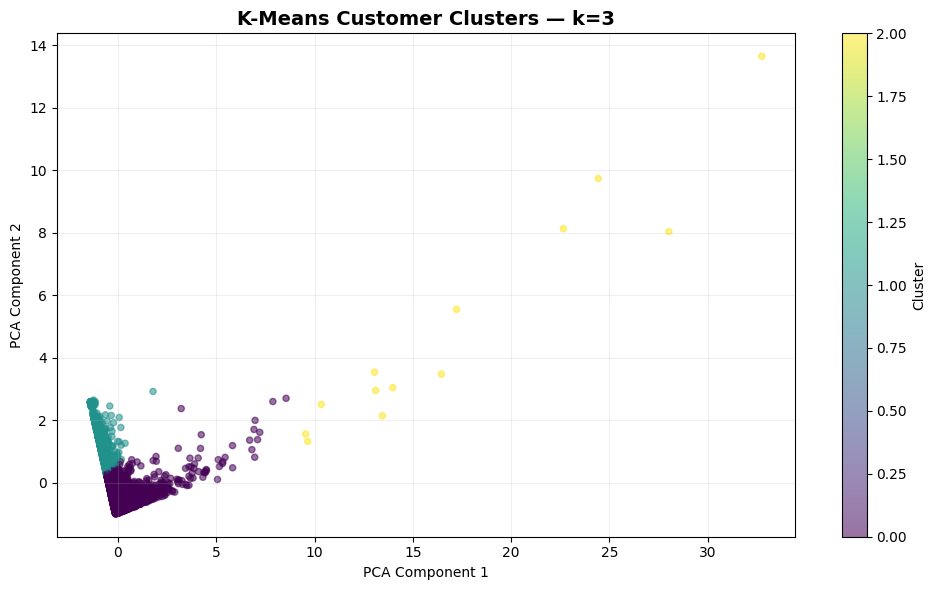

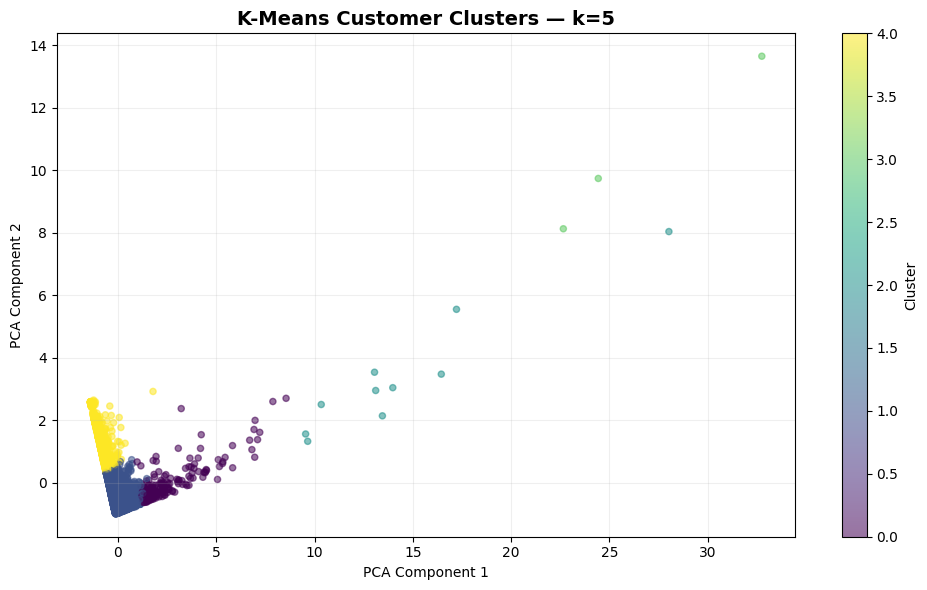

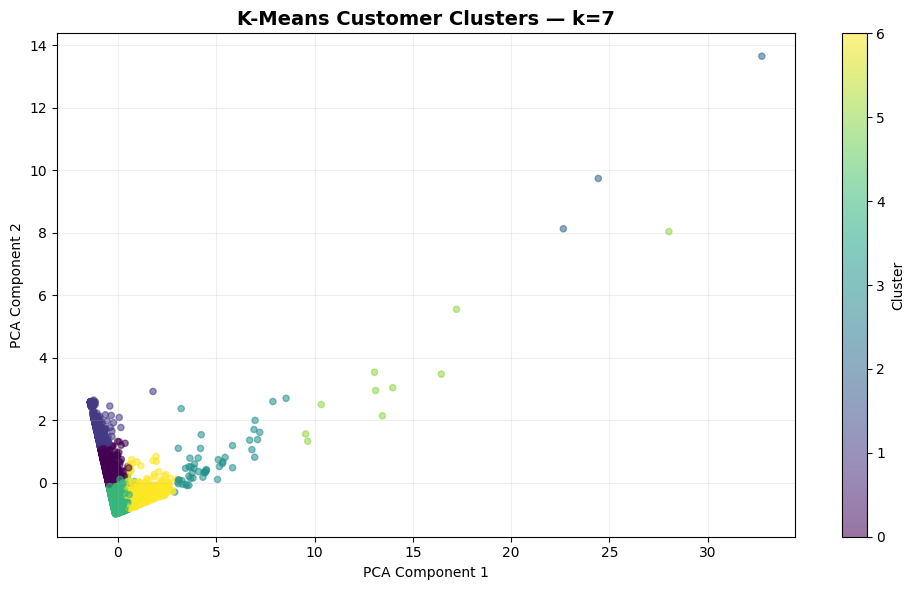

In [47]:
# Chart 2-4: K-Means cluster visualisations.
# Purpose:
# Compare how k=3, k=5 and k=7 divide the customer space.

for k in k_values:
    labels = kmeans_label_tables[k][f"KMeans_k{k}_Cluster"].values
    plot_customer_clusters(
        pca_table=pca_view,
        labels=labels,
        title=f"K-Means Customer Clusters — k={k}"
    )

#### Explanation after the K-Means charts

The charts show how the same customer space is divided when `k` changes.

How to read them:

| k | Visual/business meaning |
|---:|---|
| 3 | Simple segmentation, but may hide important high-value groups |
| 5 | More detailed segmentation while still understandable |
| 7 | More granular, but starts to split customers into smaller groups |

#### What your output suggests

The `k=5` solution gives the best balance:

- enough detail to separate inactive, regular, active high-value and VIP/outlier customers,
- not too many clusters,
- strongest Silhouette among tested K-Means values.

So the charts support the metric-based decision: **use K-Means k=5**.

### 6. K-Means elbow curve

The elbow method helps us choose a reasonable number of clusters.

K-Means inertia always decreases when `k` increases.  
So we look for the point where the improvement starts becoming smaller.

That point is called the **elbow**.

In [48]:
# -----------------------------
# Elbow curve for k = 1 to 10
# -----------------------------
# elbow_results stores inertia for each k.
# The marked elbow is estimated using the largest distance-to-line method.

elbow_records = []

for k in range(1, 11):
    # Fit K-Means for the current k.
    model = KMeans(n_clusters=k, random_state=42, n_init=20)
    model.fit(X_scaled)

    # Store inertia for elbow analysis.
    elbow_records.append({
        "k": k,
        "Inertia": model.inertia_
    })

elbow_df = pd.DataFrame(elbow_records)

# Estimate elbow using a simple geometric method.
# We draw a line from the first to the last point.
# The elbow is the point farthest from that line.
points = elbow_df[["k", "Inertia"]].values
first_point = points[0]
last_point = points[-1]

line_vector = last_point - first_point
line_vector_norm = line_vector / np.sqrt(np.sum(line_vector ** 2))

distances = []
for point in points:
    vector_from_first = point - first_point
    projection_length = np.dot(vector_from_first, line_vector_norm)
    projection_point = first_point + projection_length * line_vector_norm
    distance_to_line = np.sqrt(np.sum((point - projection_point) ** 2))
    distances.append(distance_to_line)

elbow_df["Distance_To_Line"] = distances
estimated_elbow_k = int(elbow_df.loc[elbow_df["Distance_To_Line"].idxmax(), "k"])

print("Estimated elbow k:", estimated_elbow_k)

elbow_df

Estimated elbow k: 4


,k,Inertia,Distance_To_Line
0,1,12936.000000,0.000000e+00
1,2,8697.754393,2.264414e+00
2,3,5160.291653,3.989066e+00
3,4,3587.352270,4.200587e+00
4,5,2740.115385,3.853153e+00
5,6,2235.999258,3.241437e+00
6,7,1820.107075,2.561769e+00
7,8,1560.099382,1.762035e+00
8,9,1401.947440,8.838480e-01
9,10,1251.145623,6.821210e-13


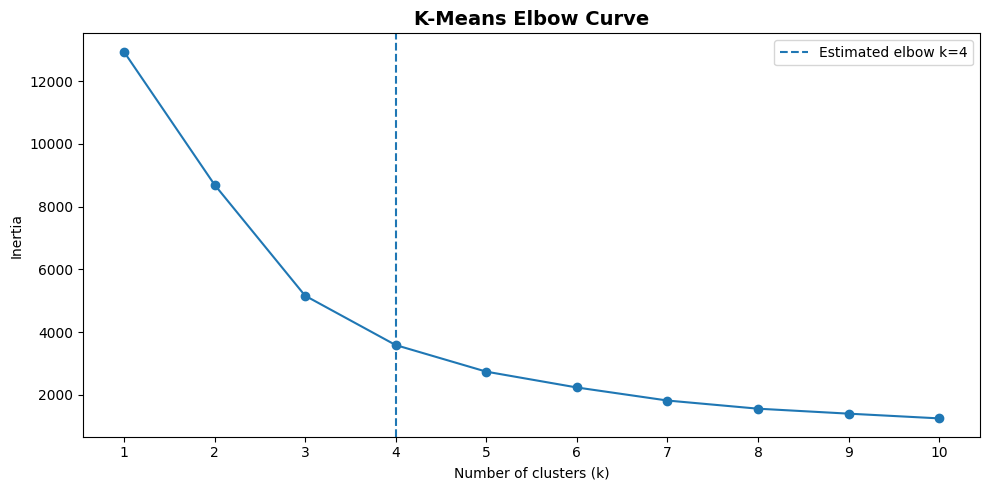

In [49]:
# Chart 5: Elbow curve.
# Purpose:
# Show the inertia drop as k increases and mark the estimated elbow.

plt.figure(figsize=(10, 5))
plt.plot(elbow_df["k"], elbow_df["Inertia"], marker="o")
plt.axvline(estimated_elbow_k, linestyle="--", label=f"Estimated elbow k={estimated_elbow_k}")
plt.title("K-Means Elbow Curve", fontsize=14, weight="bold")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(elbow_df["k"])
plt.legend()
plt.tight_layout()
plt.show()

The elbow curve estimates where adding more clusters starts giving smaller improvement.

Your executed output estimated:

> **Elbow k = 4**

This is useful, but the assignment specifically asks us to test:

- `k=3`
- `k=5`
- `k=7`

Since `k=4` was not one of the direct assignment values,

and `k=5` had the best Silhouette among the tested K-Means models,

this notebook carries forward **K-Means k=5**.

#### Recommendation

Use **K-Means k=5** for the partitioning baseline.  
Notebook 5 will revisit optimal cluster count with the **Gap Statistic**.

### 7. Understand the K-Means customer groups

K-Means gave us cluster numbers, but numbers alone are useless.

`Cluster 0` or `Cluster 2` does not tell us what kind of customers are inside.

So now we profile each cluster using the original RFM values:

- **Recency**: did they buy recently?
- **Frequency**: do they buy often?
- **Monetary**: do they spend a lot?

This helps us turn technical labels into business names, such as:

| Pattern | Business meaning |
|---|---|
| Recent + frequent + high spend | High-value active customers |
| Old purchase + low frequency + low spend | Inactive low-value customers |
| Very small group + very high spend | VIP or outlier customers |

This step is where `Cluster 0` becomes a real customer segment we can explain and use.

In [50]:
# Show the business profile table for each K-Means version.

# We tested K-Means with k = 3, 5 and 7.
# Each k creates a different number of customer groups.

# kmeans_profiles is a dictionary:
# - kmeans_profiles[3] = profile table for K-Means k=3
# - kmeans_profiles[5] = profile table for K-Means k=5
# - kmeans_profiles[7] = profile table for K-Means k=7

for k in k_values:
    
    # Print a clear heading before each profile table.
    print(f"\nK-Means Profile for k={k}")
    
    # Display the cluster profile table for this k.
    # This table helps us understand what each cluster means in business terms.
    display(kmeans_profiles[k])


K-Means Profile for k=3


,Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Method,Customer_Share_%,Revenue_Share_%
0,0,3239,42.26,4.94,2073.32,6715472.54,K-Means k=3,75.12,76.33
1,1,1060,241.68,1.65,590.70,626145.13,K-Means k=3,24.58,7.12
2,2,13,4.23,111.54,112047.39,1456616.06,K-Means k=3,0.30,16.56



K-Means Profile for k=5


,Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Method,Customer_Share_%,Revenue_Share_%
0,0,208,16.77,21.76,12210.23,2539728.08,K-Means k=5,4.82,28.87
1,1,3053,44.70,3.77,1370.06,4182795.98,K-Means k=5,70.80,47.54
2,2,10,3.70,118.10,66250.55,662505.47,K-Means k=5,0.23,7.53
3,3,3,6.00,89.67,264703.53,794110.59,K-Means k=5,0.07,9.03
4,4,1038,243.86,1.66,596.43,619093.61,K-Means k=5,24.07,7.04



K-Means Profile for k=7


,Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Method,Customer_Share_%,Revenue_Share_%
0,0,763,155.22,2.18,747.79,570563.98,K-Means k=7,17.69,6.48
1,1,593,290.08,1.43,548.64,325341.11,K-Means k=7,13.75,3.70
2,2,3,6.00,89.67,264703.53,794110.59,K-Means k=7,0.07,9.03
3,3,49,16.55,36.22,25639.57,1256339.01,K-Means k=7,1.14,14.28
4,4,2385,38.40,3.05,1086.33,2590908.23,K-Means k=7,55.31,29.45
5,5,10,3.70,118.10,66250.55,662505.47,K-Means k=7,0.23,7.53
6,6,509,20.09,12.18,5105.04,2598465.34,K-Means k=7,11.80,29.53


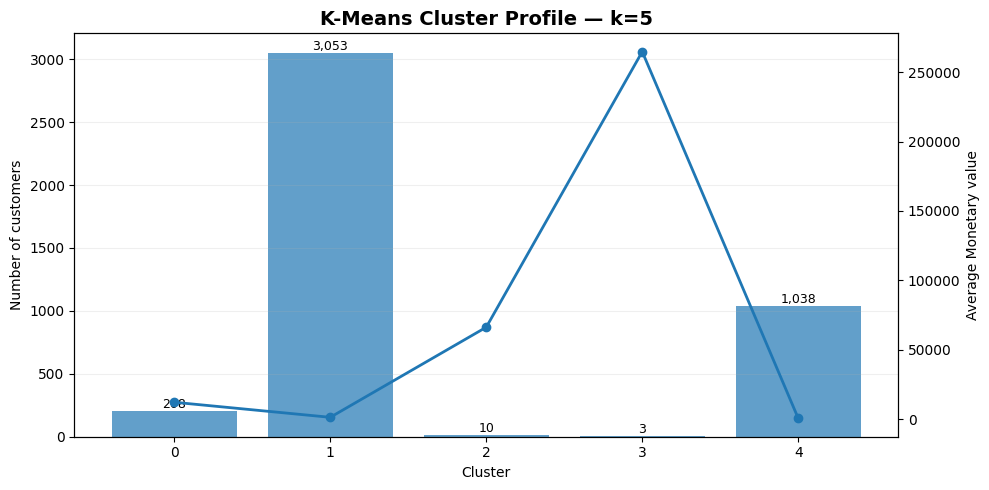

In [51]:
# Chart 6: K-Means cluster profile
# Purpose:
# Show customer count and average monetary value for the selected K-Means solution.

selected_kmeans_k = estimated_elbow_k if estimated_elbow_k in k_values else 5

plot_cluster_business_profile(
    cluster_summary=kmeans_profiles[selected_kmeans_k],
    chart_title=f"K-Means Cluster Profile — k={selected_kmeans_k}"
)

#### K-Means business profiles

The profile tables translate cluster labels into business meaning.

Your `k=5` result produced these key groups:

| Cluster | Customers | Avg Recency | Avg Frequency | Avg Monetary | Business meaning |
|---:|---:|---:|---:|---:|---|
| 0 | 208 | 16.77 | 21.76 | 12,210.23 | Recent, frequent, high-value customers |
| 1 | 3,053 | 44.70 | 3.77 | 1,370.06 | Main regular customer base |
| 2 | 10 | 3.70 | 118.10 | 66,250.55 | Very high-value frequent VIP group |
| 3 | 3 | 6.00 | 89.67 | 264,703.53 | Extreme VIP/outlier group |
| 4 | 1,038 | 243.86 | 1.66 | 596.43 | Inactive low-frequency customers |

## Business interpretation

- **Cluster 1** is the main customer base. Use standard retention and cross-sell campaigns.
- **Cluster 4** is inactive and low frequency. Use reactivation campaigns.
- **Clusters 2 and 3** are tiny but extremely valuable. Treat them as VIP/outlier groups, not normal mass-market clusters.
- **Cluster 0** is active and high value. Use loyalty rewards and premium offers.

This is why K-Means k=5 is a strong baseline.

### 8. Check whether outliers are affecting K-Means

K-Means uses average cluster centers.

That means a few extreme customers can pull the cluster center and change the result.

In Online Retail, extreme customers are not always bad.

They may be:

- VIP customers,
- wholesale buyers,
- very frequent buyers,
- very high-spend customers,
- or very inactive customers.

So we do not remove them immediately.

First, we check them.

In this section, we detect unusual customers using four methods:

| Method | Simple meaning |
|---|---|
| Top 1% rule | Finds customers with extremely high RFM values |
| IQR rule | Finds values far outside the normal range |
| Isolation Forest | Finds unusual customers using machine learning |
| Local Outlier Factor | Finds customers that look different from nearby customers |

Then we compare two K-Means results:

```text
1. K-Means with all customers
2. K-Means after removing strong outliers

In [52]:
# ------------------------------------------------------------
# 8.1 Detect outliers and connect them to K-Means clusters
# ------------------------------------------------------------
# Goal:
# Check if unusual customers are sitting inside specific K-Means clusters.

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

# Get the K-Means labels for the selected k value.
selected_kmeans_labels = kmeans_label_tables[selected_kmeans_k][f"KMeans_k{selected_kmeans_k}_Cluster"].values

# Create one table with customer RFM values + K-Means cluster.
outlier_table = rfm[["CustomerID", "Recency", "Frequency", "Monetary"]].copy()
outlier_table["KMeans_Cluster"] = selected_kmeans_labels


# ------------------------------------------------------------
# Method 1: Top 1% rule
# ------------------------------------------------------------
# Mark customers who are in the top 1% for Recency, Frequency, or Monetary.

for feature in ["Recency", "Frequency", "Monetary"]:
    top_1_percent_value = outlier_table[feature].quantile(0.99)
    outlier_table[f"{feature}_Top1Pct_Flag"] = outlier_table[feature] >= top_1_percent_value


# ------------------------------------------------------------
# Method 2: IQR rule
# ------------------------------------------------------------
# Mark customers whose values are far above the normal range.

for feature in ["Recency", "Frequency", "Monetary"]:
    q1 = outlier_table[feature].quantile(0.25)
    q3 = outlier_table[feature].quantile(0.75)
    iqr = q3 - q1
    upper_limit = q3 + 1.5 * iqr

    outlier_table[f"{feature}_IQR_Flag"] = outlier_table[feature] > upper_limit


# ------------------------------------------------------------
# Method 3: Isolation Forest
# ------------------------------------------------------------
# Machine learning method that finds unusual customers in scaled RFM data.

isolation_model = IsolationForest(
    contamination=0.02,
    random_state=42
)

outlier_table["IsolationForest_Outlier"] = isolation_model.fit_predict(X_scaled) == -1


# ------------------------------------------------------------
# Method 4: Local Outlier Factor
# ------------------------------------------------------------
# Finds customers that look different from nearby customers.

lof_model = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.02
)

outlier_table["LOF_Outlier"] = lof_model.fit_predict(X_scaled) == -1


# ------------------------------------------------------------
# Combine all outlier checks
# ------------------------------------------------------------
# Count how many methods marked each customer as unusual.

flag_columns = [
    column for column in outlier_table.columns
    if column.endswith("_Flag") or column.endswith("_Outlier")
]

outlier_table["Outlier_Flag_Count"] = outlier_table[flag_columns].sum(axis=1)

# Strong outlier = customer marked by at least 2 methods.
outlier_table["Strong_Outlier_Flag"] = outlier_table["Outlier_Flag_Count"] >= 2


# ------------------------------------------------------------
# Summarise outliers by K-Means cluster
# ------------------------------------------------------------
# This shows which K-Means clusters contain more unusual customers.

outlier_cluster_summary = (
    outlier_table
    .groupby("KMeans_Cluster")
    .agg(
        Customers=("CustomerID", "count"),
        Strong_Outliers=("Strong_Outlier_Flag", "sum"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Monetary=("Monetary", "mean")
    )
    .reset_index()
)

outlier_cluster_summary["Strong_Outlier_%"] = (
    outlier_cluster_summary["Strong_Outliers"] /
    outlier_cluster_summary["Customers"] * 100
)

outlier_cluster_summary = outlier_cluster_summary.round(2)

print("Strong outliers detected:", int(outlier_table["Strong_Outlier_Flag"].sum()))
display(outlier_cluster_summary)

Strong outliers detected: 311


,KMeans_Cluster,Customers,Strong_Outliers,Avg_Recency,Avg_Frequency,Avg_Monetary,Strong_Outlier_%
0,0,208,188,16.77,21.76,12210.23,90.38
1,1,3053,34,44.70,3.77,1370.06,1.11
2,2,10,10,3.70,118.10,66250.55,100.00
3,3,3,3,6.00,89.67,264703.53,100.00
4,4,1038,76,243.86,1.66,596.43,7.32


### What the outlier table means

The outlier check found **311 strong outlier customers**.

A strong outlier means:

> The customer was marked as unusual by at least 2 outlier detection methods.

This does not mean the customer is wrong or should be deleted.  
It means the customer behaves very differently from normal customers.

---

### What we see by cluster

| Cluster | What happened | Meaning |
|---:|---|---|
| 0 | 188 out of 208 customers are strong outliers | Mostly active high-value customers |
| 1 | Only 34 out of 3,053 customers are strong outliers | Main normal customer base |
| 2 | 10 out of 10 customers are strong outliers | Very high-value VIP group |
| 3 | 3 out of 3 customers are strong outliers | Extreme VIP / wholesale-style group |
| 4 | 76 out of 1,038 customers are strong outliers | Mostly inactive customers, with some unusual cases |

---

### Simple interpretation

K-Means created some clusters that are clearly outlier-heavy.

Clusters **2 and 3** are 100% strong outliers.  
That makes sense because they have extremely high Frequency and Monetary values.

Cluster **0** is also outlier-heavy, with **90.38% strong outliers**.  
This group looks like active high-value customers.

Cluster **1** is the safest normal customer group.  
It has only **1.11% strong outliers**.

Cluster **4** looks like an inactive customer group.  
Its average Recency is very high, meaning these customers have not bought for a long time.

---

### Business meaning

We should not blindly remove these outliers.

In this dataset, many outliers are probably important customers:

- VIP buyers,
- wholesale buyers,
- very frequent buyers,
- very high-spend customers.

So the better decision is:

> Keep outliers visible, but explain them separately.

---

### Recommendation

For this notebook:

- Use **K-Means k=5** as the main segmentation.
- Treat clusters **2 and 3** as VIP/outlier groups.
- Treat cluster **0** as an active high-value group.
- Treat cluster **1** as the main normal customer base.
- Treat cluster **4** as the inactive customer group.

Next, we compare K-Means with and without strong outliers to see how much these unusual customers affect the clustering result.

In [53]:
# ------------------------------------------------------------
# 8.2 Test whether outliers change the K-Means result
# ------------------------------------------------------------

# We compare:
# - K-Means on all customers
# - K-Means after removing strong outliers

# This does not mean outliers should be removed permanently.
# It only checks how sensitive the segmentation is.

# Keep customers that are not strong outliers.

normal_customer_mask = ~outlier_table["Strong_Outlier_Flag"].values

X_scaled_without_strong_outliers = X_scaled.loc[normal_customer_mask].copy()
rfm_without_strong_outliers = rfm.loc[normal_customer_mask].copy()

# Run K-Means again on the non-outlier customer group.

kmeans_without_outliers = KMeans(
    n_clusters=selected_kmeans_k,
    random_state=42,
    n_init=20
)

labels_without_outliers = kmeans_without_outliers.fit_predict(X_scaled_without_strong_outliers)

# Metrics for original selected K-Means result.

full_data_metrics = calculate_clustering_scores(X_scaled, selected_kmeans_labels)

# Metrics for K-Means after removing strong outliers.

without_outliers_metrics = calculate_clustering_scores(
    X_scaled_without_strong_outliers,
    labels_without_outliers
)

# Build comparison table.

outlier_sensitivity_comparison = pd.DataFrame([
    {
        "Version": "All customers",
        "Customers": len(X_scaled),
        "Strong_Outliers_Removed": 0,
        "Inertia": np.nan,
        **full_data_metrics
    },
    {
        "Version": "Without strong outliers",
        "Customers": len(X_scaled_without_strong_outliers),
        "Strong_Outliers_Removed": int(outlier_table["Strong_Outlier_Flag"].sum()),
        "Inertia": kmeans_without_outliers.inertia_,
        **without_outliers_metrics
    }
]).round(4)

display(outlier_sensitivity_comparison)

,Version,Customers,Strong_Outliers_Removed,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,All customers,4312,0,NaN,0.6140,0.6304,4006.5535
1,Without strong outliers,4001,311,452.8936,0.4255,0.7399,8213.9582


### What this comparison means

We tested K-Means in two ways:

| Version | Meaning |
|---|---|
| All customers | K-Means uses every customer, including VIP and unusual customers |
| Without strong outliers | K-Means removes the 311 strongest outlier customers first |

---

### What changed?

| Metric | All customers | Without strong outliers | Meaning |
|---|---:|---:|---|
| Customers | 4,312 | 4,001 | 311 unusual customers removed |
| Silhouette | **0.6140** | 0.4255 | Cluster separation became worse |
| Davies-Bouldin | **0.6304** | 0.7399 | Clusters became less clean |
| Calinski-Harabasz | 4006.55 | **8213.96** | Structure became stronger numerically, but this alone is not enough |

---

### Simple interpretation

Removing strong outliers did **not** improve the K-Means result.

The most important score here is **Silhouette**.

Silhouette dropped from:

```text
0.6140 → 0.4255

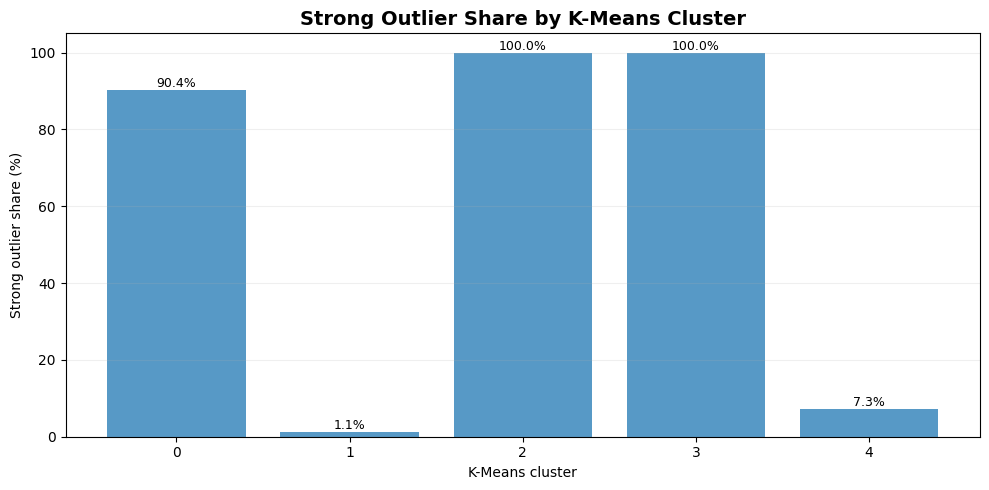

In [54]:
# ------------------------------------------------------------
# 8.3 Visualise outlier concentration by K-Means cluster
# ------------------------------------------------------------

# This chart shows which K-Means clusters contain more strong outliers.

plt.figure(figsize=(10, 5))

bars = plt.bar(
    outlier_cluster_summary["KMeans_Cluster"].astype(str),
    outlier_cluster_summary["Strong_Outlier_%"],
    alpha=0.75
)

plt.title("Strong Outlier Share by K-Means Cluster", fontsize=14, weight="bold")
plt.xlabel("K-Means cluster")
plt.ylabel("Strong outlier share (%)")
plt.grid(axis="y", alpha=0.2)

for bar in bars:
    value = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

#### 9. MiniBatchKMeans

#### Theory recap

MiniBatchKMeans is a faster version of K-Means.

Instead of using all customers at every update, it uses small random batches.

### Why this method is used here

Online Retail after RFM aggregation is not extremely large.
  
Normal K-Means should run fine.

But MiniBatchKMeans is useful in real business settings where the customer base is much larger.

In [55]:
# -----------------------------
# MiniBatchKMeans comparison
# -----------------------------
# We use the selected K-Means k so the comparison is fair.
# minibatch_labels stores the customer cluster labels.

start_time = time.time()

minibatch_model = MiniBatchKMeans(
    n_clusters=selected_kmeans_k,
    random_state=42,
    n_init=20,
    batch_size=256
)

minibatch_labels = minibatch_model.fit_predict(X_scaled)

minibatch_runtime = time.time() - start_time

minibatch_metrics = calculate_clustering_scores(X_scaled, minibatch_labels)

minibatch_results = pd.DataFrame([{
    "Method": "MiniBatchKMeans",
    "k": selected_kmeans_k,
    "Clusters": len(np.unique(minibatch_labels)),
    "Inertia": minibatch_model.inertia_,
    "Runtime_Seconds": minibatch_runtime,
    **minibatch_metrics
}]).round(4)

minibatch_profile = create_cluster_summary(rfm, minibatch_labels, "MiniBatchKMeans")

minibatch_results

,Method,k,Clusters,Inertia,Runtime_Seconds,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,MiniBatchKMeans,5,5,4960.432,0.4714,0.4978,0.8053,2038.1327


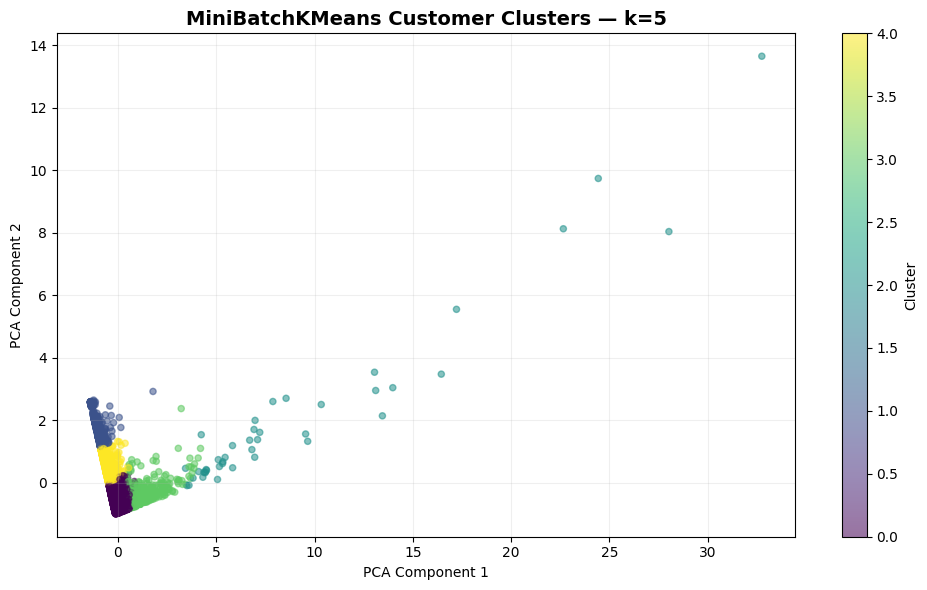

In [56]:
# Chart 7: MiniBatchKMeans cluster visualisation.
# Purpose:
# See whether MiniBatchKMeans creates a similar customer split to K-Means.

plot_customer_clusters(
    pca_table=pca_view,
    labels=minibatch_labels,
    title=f"MiniBatchKMeans Customer Clusters — k={selected_kmeans_k}"
)

### What the MiniBatchKMeans result means

MiniBatchKMeans is the faster version of K-Means.

It created **5 clusters** in only **0.055 seconds**.

That is very fast.

But the quality is weaker than normal K-Means.

| Metric | MiniBatchKMeans | Meaning |
|---|---:|---|
| Silhouette | 0.4978 | Lower than K-Means k=5, so clusters are less clearly separated |
| Davies-Bouldin | 0.8053 | Higher than K-Means k=5, so clusters are more mixed |
| Calinski-Harabasz | 2038.13 | Much lower than K-Means k=5, so structure is weaker |
| Inertia | 4960.43 | Higher than K-Means k=5, so customers are less tightly grouped |

### Simple conclusion

MiniBatchKMeans is faster, but worse for this dataset.

For this project:

```text
K-Means k=5 > MiniBatchKMeans

#### Explanation after MiniBatchKMeans

MiniBatchKMeans tested whether a faster K-Means version gives similar quality.

Your executed output shows:


| Metric | Value |
|---|---:|
| Runtime | 0.0557 seconds |
| Silhouette | 0.4978 |
| Davies-Bouldin | 0.8053 |
| Calinski-Harabasz | 2038.13 |

#### Interpretation

MiniBatchKMeans was fast, but the clustering quality was weaker than normal K-Means k=5.


| Metric | K-Means k=5 | MiniBatchKMeans |
|---|---:|---:|
| Silhouette | 0.6140 | 0.4978 |
| Davies-Bouldin | 0.6304 | 0.8053 |
| Calinski-Harabasz | 4006.55 | 2038.13 |

#### Recommendation

Use MiniBatchKMeans only when the dataset becomes much larger and runtime matters more than best segmentation quality.

For this project, normal **K-Means k=5** is better.

#### 10. K-Modes

#### Theory recap

K-Modes is used for categorical data.

K-Means uses averages.  
K-Modes uses the most common category, called the **mode**.

#### Why this method is used here

K-Modes lets us cluster using category patterns such as:

- country,
- dominant product,
- Recency group,
- Frequency group,
- Monetary group.

In [57]:
# -----------------------------
# Prepare categorical data for K-Modes
# -----------------------------
# kmodes_features contains only categorical customer features.
# CustomerID is kept separately because it is an identifier, not a clustering feature.

kmodes_feature_columns = [
    "Country",
    "DominantProduct",
    "RecencyGroup",
    "FrequencyGroup",
    "MonetaryGroup"
]

kmodes_data = customer_categories[kmodes_feature_columns].copy()

# Fill missing values with text so categorical algorithms do not fail.
kmodes_data = kmodes_data.fillna("Unknown").astype(str)

print("K-Modes input shape:", kmodes_data.shape)
kmodes_data.head()

K-Modes input shape: (4312, 5)


,Country,DominantProduct,RecencyGroup,FrequencyGroup,MonetaryGroup
0,United Kingdom,DOORMAT 3 SMILEY CATS,Inactive,High Frequency,Low Monetary
1,Iceland,3D DOG PICTURE PLAYING CARDS,Recent,Low Frequency,High Monetary
2,Finland,36 DOILIES VINTAGE CHRISTMAS,Warm,Low Frequency,Low Monetary
3,Italy,LOVE HEART SOCK HANGER,Warm,Medium Frequency,High Monetary
4,Unspecified,BLUE SCANDINAVIAN PAISLEY WRAP,Recent,Low Frequency,Low Monetary


### What the K-Modes input means

K-Modes does not use normal numbers like Recency, Frequency and Monetary.

It uses **categories**.

Here, we prepared **4,312 customers** with **5 categorical features**:

| Column | Meaning |
|---|---|
| Country | Customer’s main country |
| DominantProduct | Product the customer bought most often |
| RecencyGroup | Recent, Warm, or Inactive |
| FrequencyGroup | Low, Medium, or High Frequency |
| MonetaryGroup | Low, Medium, or High Monetary |

Each row is one customer.

Example:

```text
United Kingdom | DOORMAT 3 SMILEY CATS | Inactive | High Frequency | Low Monetary

In [58]:
# -----------------------------
# Install/import K-Modes
# -----------------------------

# K-Modes is available from the kmodes package.
# If installation is not possible, we use a clear fallback below.

def install_package_if_missing(package_name, import_name):
    
    # Try importing first.
    # If it fails, install into the current notebook environment.
    
    try:
        return importlib.import_module(import_name)
    except ImportError:
        print(f"{import_name} is missing. Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        importlib.invalidate_caches()
        return importlib.import_module(import_name)


try:
    kmodes_module = install_package_if_missing("kmodes", "kmodes.kmodes")
    from kmodes.kmodes import KModes
    kmodes_available = True
    print("KModes is available.")
    
except Exception as error:
    kmodes_available = False
    
    
    print("KModes could not be installed/imported.")
    print("Fallback categorical clustering will be used.")
    print("Reason:", error)

KModes is available.


In [59]:
# -----------------------------
# Run K-Modes or fallback categorical clustering
# -----------------------------

# k_modes_k sets the number of categorical clusters.
# We use the same selected k as K-Means when possible.

k_modes_k = selected_kmeans_k

if kmodes_available:
    
    # KModes clusters customers using category mismatch distance.
    
    kmodes_model = KModes(
        n_clusters=k_modes_k,
        init="Huang",
        n_init=5,
        random_state=42
    )

    kmodes_labels = kmodes_model.fit_predict(kmodes_data)
    kmodes_cost = kmodes_model.cost_
    kmodes_method_used = "K-Modes"
    
else:
    
    # Fallback:
    # Encode categories as ordinal numbers and run K-Means.
    # This is not true K-Modes, so we clearly mark it as a fallback.
    
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    encoded_categories = encoder.fit_transform(kmodes_data)

    fallback_model = KMeans(n_clusters=k_modes_k, random_state=42, n_init=20)
    kmodes_labels = fallback_model.fit_predict(encoded_categories)

    kmodes_cost = np.nan
    kmodes_method_used = "K-Modes fallback using encoded categories"

kmodes_result_table = rfm[["CustomerID"]].copy()
kmodes_result_table["KModes_Cluster"] = kmodes_labels

kmodes_profile = create_cluster_summary(rfm, kmodes_labels, kmodes_method_used)

print("Method used:", kmodes_method_used)
print("Clusters:", len(np.unique(kmodes_labels)))
print("K-Modes cost:", kmodes_cost)

kmodes_profile

Method used: K-Modes
Clusters: 5
K-Modes cost: 6679.0


,Cluster,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Monetary,Method,Customer_Share_%,Revenue_Share_%
0,0,1247,193.78,1.44,460.20,573872.65,K-Modes,28.92,6.52
1,1,845,63.39,2.94,827.30,699069.10,K-Modes,19.60,7.95
2,2,523,54.96,1.23,393.65,205880.56,K-Modes,12.13,2.34
3,3,574,54.98,3.06,1129.24,648186.16,K-Modes,13.31,7.37
4,4,1123,33.50,11.15,5940.54,6671225.26,K-Modes,26.04,75.82


### What the K-Modes result means

K-Modes successfully created **5 customer groups** using categorical patterns.

It used:

- Country
- Dominant product
- Recency group
- Frequency group
- Monetary group

The K-Modes cost is:

```text
6679.0

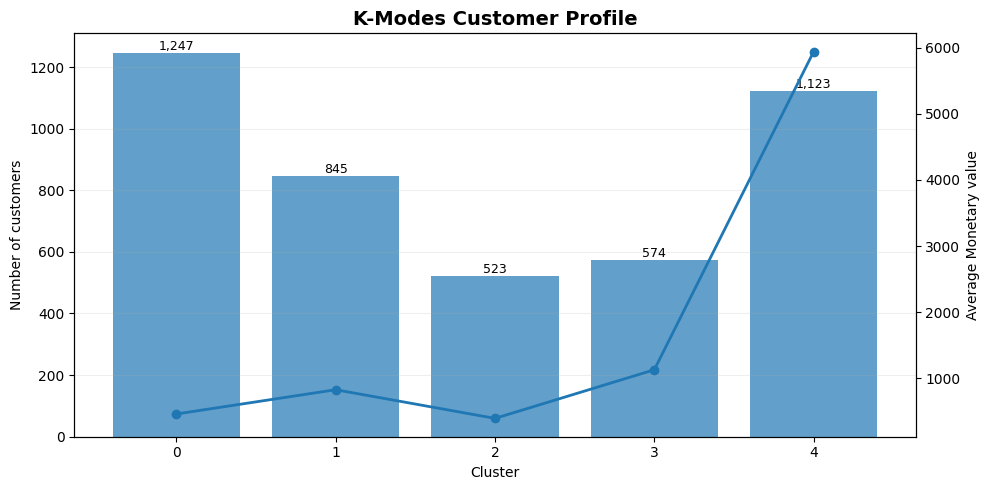

In [60]:
# Chart 8: K-Modes cluster profile.
# Purpose:
# Show how categorical pattern clusters differ in customer count and average monetary value.

plot_cluster_business_profile(
    profile=kmodes_profile,
    title="K-Modes Customer Profile"
)

K-Modes gives a categorical view of customers.

It asks:

> Which customers share similar country, product and RFM-category patterns?

Your executed output found one very important categorical segment:

| Cluster | Customers | Avg Recency | Avg Frequency | Avg Monetary | Revenue Share |
|---:|---:|---:|---:|---:|---:|
| 4 | 1,123 | 33.50 | 11.15 | 5,940.54 | 75.82% |

#### Business interpretation

This is a very strong high-value category-based segment.

It contains about **26.04% of customers** but contributes about **75.82% of revenue**.

#### Recommendation

Use K-Modes as a **supporting business explanation layer**.

It does not win numerical RFM metrics, but it is highly useful for explaining category-based customer behaviour.

### 11. K-Medoids

#### Theory recap

K-Medoids is similar to K-Means, but it uses real customers as cluster representatives.

| Method | Representative |
|---|---|
| K-Means | Average centroid |
| K-Medoids | Real customer from the dataset |

#### Why this method is useful

K-Medoids can be more robust to extreme customers.

If one customer has unusually high Monetary value, K-Means centroids can be pulled toward that extreme value.  
K-Medoids chooses real representative customers, which can be easier to explain.

In [61]:
# -----------------------------
# K-Medoids from sklearn-extra
# -----------------------------

# sklearn-extra is not part of default sklearn.

# If it cannot be installed, we use a simplified medoid-style fallback.

try:
    sklearn_extra_cluster = install_package_if_missing("scikit-learn-extra", "sklearn_extra.cluster")
    from sklearn_extra.cluster import KMedoids
    kmedoids_available = True
    print("KMedoids is available.")
    
except Exception as error:
    kmedoids_available = False
    print("KMedoids could not be installed/imported.")
    print("Using simplified medoid-style fallback.")
    print("Reason:", error)

KMedoids could not be installed/imported.
Using simplified medoid-style fallback.
Reason: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject


In [62]:
# ------------------------------------------------------------
# Run K-Medoids or medoid-style fallback
# ------------------------------------------------------------
# Goal:
# Create clusters using real customer representatives.
#
# This cell checks whether KMedoids is available.
# If not, it automatically uses a medoid-style fallback.

try:
    from sklearn_extra.cluster import KMedoids
    kmedoids_available = True
    print("KMedoids is available. Using true K-Medoids.")
except Exception as error:
    kmedoids_available = False
    print("KMedoids is not available. Using medoid-style fallback.")
    print("Reason:", error)

# Use the same k as selected K-Means.
kmedoids_k = selected_kmeans_k

if kmedoids_available:

    kmedoids_model = KMedoids(
        n_clusters=kmedoids_k,
        random_state=42,
        metric="euclidean",
        init="k-medoids++"
    )

    kmedoids_labels = kmedoids_model.fit_predict(X_scaled)
    kmedoids_method_used = "K-Medoids"

else:

    base_kmeans = KMeans(
        n_clusters=kmedoids_k,
        random_state=42,
        n_init=20
    )

    base_labels = base_kmeans.fit_predict(X_scaled)

    medoid_indices = []

    for cluster_id in range(kmedoids_k):

        cluster_points = X_scaled[base_labels == cluster_id]
        cluster_index_values = X_scaled.index[base_labels == cluster_id]

        cluster_center = cluster_points.mean(axis=0).values

        distances_to_center = np.sqrt(
            ((cluster_points.values - cluster_center) ** 2).sum(axis=1)
        )

        closest_position = distances_to_center.argmin()
        closest_customer_index = cluster_index_values[closest_position]
        medoid_indices.append(closest_customer_index)

    medoid_points = X_scaled.loc[medoid_indices].values

    all_distances = np.sqrt(
        ((X_scaled.values[:, None, :] - medoid_points[None, :, :]) ** 2).sum(axis=2)
    )

    kmedoids_labels = all_distances.argmin(axis=1)
    kmedoids_method_used = "Medoid-style fallback"

# Calculate clustering scores.
kmedoids_metrics = calculate_clustering_scores(X_scaled, kmedoids_labels)

# Create business summary table.
kmedoids_profile = create_cluster_summary(
    rfm,
    kmedoids_labels,
    kmedoids_method_used
)

# Store final result in one table.
kmedoids_results = pd.DataFrame([{
    "Method": kmedoids_method_used,
    "k": kmedoids_k,
    "Clusters": len(np.unique(kmedoids_labels)),
    **kmedoids_metrics
}]).round(4)

kmedoids_results

KMedoids is not available. Using medoid-style fallback.
Reason: numpy.dtype size changed, may indicate binary incompatibility. Expected 96 from C header, got 88 from PyObject


,Method,k,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,Medoid-style fallback,5,5,0.6146,0.6278,4004.7829


### What the Medoid-style fallback result means

The real K-Medoids package did not run in this environment, so the notebook used the fallback version.

The fallback created **5 clusters**.

| Metric | Value | Meaning |
|---|---:|---|
| Silhouette | **0.6146** | Very good separation |
| Davies-Bouldin | **0.6278** | Clean cluster structure |
| Calinski-Harabasz | 4004.78 | Strong overall structure |

### Simple interpretation

This result is very close to K-Means k=5.

| Method | Silhouette | Davies-Bouldin | Calinski-Harabasz |
|---|---:|---:|---:|
| K-Means k=5 | 0.6140 | 0.6304 | 4006.55 |
| Medoid-style fallback | **0.6146** | **0.6278** | 4004.78 |

The scores are almost the same.

This means the K-Means result is stable.

Even when we use real customer representatives instead of average centers, the cluster quality stays strong.

### Recommendation

Use this result as a **robustness check**.

Do not use it as the final main model because it is a fallback, not full K-Medoids.

Final decision:

```text
Main model        → K-Means k=5
Robustness check  → Medoid-style fallback

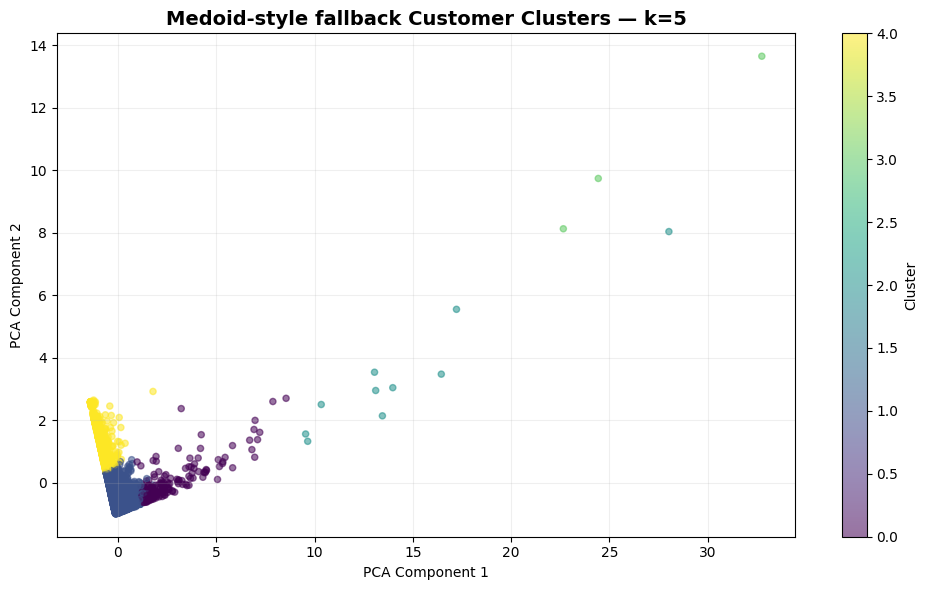

In [63]:
# Chart 9: K-Medoids / fallback cluster visualisation.
# Purpose:
# Compare robust representative-based clustering with K-Means.

plot_customer_clusters(
    pca_table=pca_view,
    labels=kmedoids_labels,
    title=f"{kmedoids_method_used} Customer Clusters — k={kmedoids_k}"
)

### What this chart shows

This chart shows the **Medoid-style fallback clusters** on the PCA customer map.

Each dot is one customer.  
Each colour is one cluster.

The chart looks very similar to the K-Means chart.

That is good.

It means the fallback method created a similar customer structure to K-Means.

---

### What we can see

Most customers are grouped tightly on the left side of the chart.

A few customers are far away on the right and upper side.

Those far-away points are unusual customers.

They are likely:

- very high spend customers,
- very frequent buyers,
- VIP-style customers,
- or outlier customers.

---

### Simple interpretation

The Medoid-style fallback confirms the same story as K-Means:

- there is one large normal customer area,
- there are some smaller special groups,
- some customers are clearly far away from the main group,
- those far-away customers should be explained separately.

---

### Business meaning

This supports our earlier decision.

K-Means k=5 is not random.

Even when we use real customer representatives, the overall structure stays similar.

So we can trust K-Means k=5 more.

---

### Recommendation

Use this chart as a **stability check**.

Final reading:

```text
K-Means k=5 = main segmentation
Medoid-style fallback = confirms the segmentation is stable
Far-away points = VIP / outlier customers to explain separately

#### K-Medoids / medoid-style fallback

The notebook used a **medoid-style fallback**.



| Metric | Value |
|---|---:|
| Silhouette | **0.6146** |
| Davies-Bouldin | **0.6278** |
| Calinski-Harabasz | 4004.78 |

#### Interpretation

The fallback was very close to K-Means k=5.

| Method | Silhouette |
|---|---:|
| K-Means k=5 | 0.6140 |
| Medoid-style fallback | 0.6146 |

#### Recommendation

Use this as a **robustness check**, not as the official final method.

Reason:

- it is a fallback approximation,
- it is not full production K-Medoids,
- K-Means k=5 is more standard and easier to defend.

The main baseline remains **K-Means k=5**.

### 12. K-Prototypes

#### Theory recap

K-Prototypes is used for mixed data.

It combines:

| Feature type | Example |
|---|---|
| Numerical | Recency, Frequency, Monetary |
| Categorical | Country, DominantProduct, RecencyGroup |

#### Why this method is useful

Customer behaviour is not only numerical.

Two customers can have similar RFM values but belong to different countries or product groups.

K-Prototypes lets us combine both types of information.

In [64]:
# -----------------------------
# Prepare mixed data for K-Prototypes
# -----------------------------

# Numerical features come from rfm.
# Categorical features come from customer_categories.
# We merge them by CustomerID.

mixed_data = (
    rfm[["CustomerID", "Recency", "Frequency", "Monetary"]]
    .merge(
        customer_categories[["CustomerID", "Country", "DominantProduct", "RecencyGroup", "FrequencyGroup", "MonetaryGroup"]],
        on="CustomerID",
        how="left"
    )
)

# Define numerical and categorical columns.
categorical_columns = ["Country", "DominantProduct", "RecencyGroup", "FrequencyGroup", "MonetaryGroup"]
numerical_columns = ["Recency", "Frequency", "Monetary"]

# Fill missing categorical values.
for column in categorical_columns:
    mixed_data[column] = mixed_data[column].fillna("Unknown").astype(str)

print("Mixed data shape:", mixed_data.shape)
mixed_data.head()

Mixed data shape: (4312, 9)


,CustomerID,Recency,Frequency,Monetary,Country,DominantProduct,RecencyGroup,FrequencyGroup,MonetaryGroup
0,12346,165,11,372.86,United Kingdom,DOORMAT 3 SMILEY CATS,Inactive,High Frequency,Low Monetary
1,12347,3,2,1323.32,Iceland,3D DOG PICTURE PLAYING CARDS,Recent,Low Frequency,High Monetary
2,12348,74,1,222.16,Finland,36 DOILIES VINTAGE CHRISTMAS,Warm,Low Frequency,Low Monetary
3,12349,43,3,2671.14,Italy,LOVE HEART SOCK HANGER,Warm,Medium Frequency,High Monetary
4,12351,11,1,300.93,Unspecified,BLUE SCANDINAVIAN PAISLEY WRAP,Recent,Low Frequency,Low Monetary


In [65]:
# -----------------------------
# K-Prototypes or fallback mixed clustering
# -----------------------------

# True K-Prototypes needs categorical column indices.
# The fallback uses scaled RFM + encoded categories with K-Means.

kprototypes_k = selected_kmeans_k

try:
    from kmodes.kprototypes import KPrototypes
    kprototypes_available = True
    print("KPrototypes is available.")
    
except Exception as error:
    kprototypes_available = False
    print("KPrototypes could not be imported.")
    print("Using mixed-feature fallback.")
    print("Reason:", error)

if kprototypes_available:
    # K-Prototypes expects a numpy array with numerical and categorical columns together.
    
    kproto_input = mixed_data[numerical_columns + categorical_columns].copy()

    # Convert numerical values to float.
    
    for column in numerical_columns:
        kproto_input[column] = pd.to_numeric(kproto_input[column], errors="coerce")

    # Convert all values to object array as expected by kmodes.
    
    kproto_array = kproto_input.to_numpy()

    # Categorical column positions start after the numerical columns.
    
    categorical_indices = list(range(len(numerical_columns), len(numerical_columns) + len(categorical_columns)))

    kproto_model = KPrototypes(
        n_clusters=kprototypes_k,
        init="Cao",
        n_init=3,
        random_state=42
    )

    kprototypes_labels = kproto_model.fit_predict(kproto_array, categorical=categorical_indices)
    kprototypes_method_used = "K-Prototypes"
    
else:
    # Fallback:
    # 1. Use scaled RFM numerical features.
    # 2. Encode categorical features.
    # 3. Combine both into one matrix.
    # 4. Run K-Means as an approximate mixed-feature clustering.
    
    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    encoded_cats = encoder.fit_transform(mixed_data[categorical_columns].astype(str))

    mixed_fallback_matrix = np.hstack([
        X_scaled.values,
        encoded_cats
    ])

    fallback_mixed_model = KMeans(n_clusters=kprototypes_k, random_state=42, n_init=20)
    kprototypes_labels = fallback_mixed_model.fit_predict(mixed_fallback_matrix)
    kprototypes_method_used = "K-Prototypes fallback using scaled RFM + encoded categories"

# Evaluate labels using numerical RFM features only.
# This keeps metrics comparable with other numerical clustering methods.

kprototypes_metrics = calculate_clustering_scores(X_scaled, kprototypes_labels)
kprototypes_profile = create_cluster_summary(rfm, kprototypes_labels, kprototypes_method_used)

kprototypes_results = pd.DataFrame([{
    "Method": kprototypes_method_used,
    "k": kprototypes_k,
    "Clusters": len(np.unique(kprototypes_labels)),
    **kprototypes_metrics
}]).round(4)

kprototypes_results

KPrototypes is available.


,Method,k,Clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Prototypes,5,5,0.3655,1.087,1024.9517


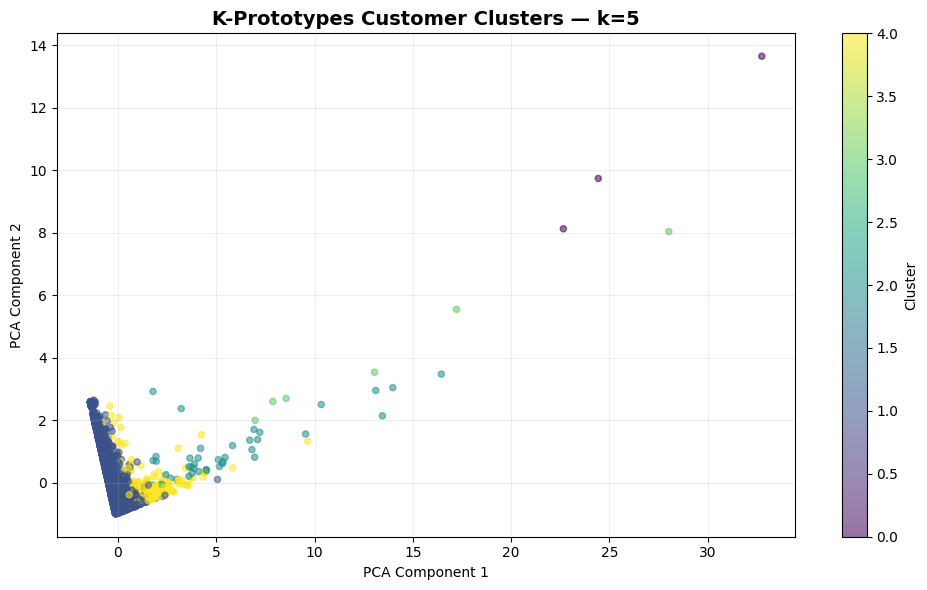

In [66]:
# Chart 10: K-Prototypes / fallback visualisation.

# Purpose:
# Visualise mixed-feature clustering labels in the same PCA space.

plot_customer_clusters(
    pca_table=pca_view,
    labels=kprototypes_labels,
    title=f"{kprototypes_method_used} Customer Clusters — k={kprototypes_k}"
)

K-Prototypes combines numerical and categorical customer features.

executed output shows:

| Metric | Value |
|---|---:|
| Silhouette | 0.3655 |
| Davies-Bouldin | 1.0870 |
| Calinski-Harabasz | 1024.95 |

#### Interpretation

K-Prototypes is useful because it combines:

- RFM behaviour,
- country,
- dominant product,
- RFM category bands.

But in this run, it was weaker than K-Means and the medoid-style fallback on numerical separation metrics.

#### Recommendation

Use K-Prototypes as an **exploratory mixed-feature method**.
  
Do not use it as the main baseline for this run.

### 13. Compare partitioning methods

#### Why this step is done

Each partitioning method gives a different view of the customer base.

We compare them using:


| Metric | Direction |
|---|---|
| Silhouette | Higher is better |
| Davies-Bouldin | Lower is better |
| Calinski-Harabasz | Higher is better |


We also consider business usefulness, not only metrics.

In [67]:
# ------------------------------------------------------------
# Create final partitioning method comparison table
# ------------------------------------------------------------
# This cell is safe to run even if MiniBatchKMeans or K-Prototypes
# was not run earlier.

comparison_tables = []

# 1. Best K-Means result
best_kmeans_row = (
    kmeans_results_df
    .sort_values("Silhouette", ascending=False)
    .head(1)
    .copy()
)

best_kmeans_k = int(best_kmeans_row["k"].iloc[0])
best_kmeans_labels = kmeans_label_tables[best_kmeans_k][f"KMeans_k{best_kmeans_k}_Cluster"].values
comparison_tables.append(best_kmeans_row)


# 2. MiniBatchKMeans result
# If missing, recreate it here.
if "minibatch_results" not in globals():

    import time

    start_time = time.time()

    minibatch_model = MiniBatchKMeans(
        n_clusters=selected_kmeans_k,
        random_state=42,
        n_init=20,
        batch_size=256
    )

    minibatch_labels = minibatch_model.fit_predict(X_scaled)
    minibatch_runtime = time.time() - start_time

    minibatch_metrics = calculate_clustering_scores(X_scaled, minibatch_labels)

    minibatch_results = pd.DataFrame([{
        "Method": "MiniBatchKMeans",
        "k": selected_kmeans_k,
        "Clusters": len(np.unique(minibatch_labels)),
        "Inertia": minibatch_model.inertia_,
        "Runtime_Seconds": minibatch_runtime,
        **minibatch_metrics
    }]).round(4)

comparison_tables.append(minibatch_results)


# 3. K-Modes result
kmodes_metrics = calculate_clustering_scores(X_scaled, kmodes_labels)

kmodes_results = pd.DataFrame([{
    "Method": kmodes_method_used,
    "k": k_modes_k,
    "Clusters": len(np.unique(kmodes_labels)),
    "Inertia": np.nan,
    "Runtime_Seconds": np.nan,
    **kmodes_metrics
}]).round(4)

comparison_tables.append(kmodes_results)


# 4. K-Medoids / fallback result
if "kmedoids_results" not in globals():
    raise NameError("kmedoids_results is missing. Run the K-Medoids / medoid-style fallback section first.")

comparison_tables.append(kmedoids_results)


# 5. K-Prototypes result
# If missing, recreate a fallback version here.
if "kprototypes_results" not in globals():

    categorical_columns = ["Country", "DominantProduct", "RecencyGroup", "FrequencyGroup", "MonetaryGroup"]

    if "mixed_data" not in globals():
        mixed_data = (
            rfm[["CustomerID", "Recency", "Frequency", "Monetary"]]
            .merge(
                customer_categories[["CustomerID"] + categorical_columns],
                on="CustomerID",
                how="left"
            )
        )

        for column in categorical_columns:
            mixed_data[column] = mixed_data[column].fillna("Unknown").astype(str)

    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    encoded_cats = encoder.fit_transform(mixed_data[categorical_columns].astype(str))

    mixed_fallback_matrix = np.hstack([
        X_scaled.values,
        encoded_cats
    ])

    fallback_mixed_model = KMeans(
        n_clusters=selected_kmeans_k,
        random_state=42,
        n_init=20
    )

    kprototypes_labels = fallback_mixed_model.fit_predict(mixed_fallback_matrix)
    kprototypes_method_used = "K-Prototypes fallback using scaled RFM + encoded categories"

    kprototypes_metrics = calculate_clustering_scores(X_scaled, kprototypes_labels)

    kprototypes_results = pd.DataFrame([{
        "Method": kprototypes_method_used,
        "k": selected_kmeans_k,
        "Clusters": len(np.unique(kprototypes_labels)),
        "Inertia": np.nan,
        "Runtime_Seconds": np.nan,
        **kprototypes_metrics
    }]).round(4)

comparison_tables.append(kprototypes_results)


# Combine all method results.
for table in comparison_tables:
    if "Inertia" not in table.columns:
        table["Inertia"] = np.nan

    if "Runtime_Seconds" not in table.columns:
        table["Runtime_Seconds"] = np.nan

partitioning_method_comparison = pd.concat(
    comparison_tables,
    ignore_index=True
)

partitioning_method_comparison = partitioning_method_comparison[
    [
        "Method",
        "k",
        "Clusters",
        "Inertia",
        "Runtime_Seconds",
        "Silhouette",
        "Davies_Bouldin",
        "Calinski_Harabasz"
    ]
].round(4)

partitioning_method_comparison

,Method,k,Clusters,Inertia,Runtime_Seconds,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means,5,5,2740.1154,NaN,0.6140,0.6304,4006.5535
1,MiniBatchKMeans,5,5,4960.4320,0.4714,0.4978,0.8053,2038.1327
2,K-Modes,5,5,NaN,NaN,-0.0544,5.4446,378.6454
3,Medoid-style fallback,5,5,NaN,NaN,0.6146,0.6278,4004.7829
4,K-Prototypes,5,5,NaN,NaN,0.3655,1.0870,1024.9517


### What the method comparison table means

This table compares all partitioning methods tested in this notebook.

The goal is to answer:

**Which method gives the clearest and most useful customer groups?**

---

### Main result

| Rank | Method | Key result | Simple meaning |
|---:|---|---:|---|
| 1 | Medoid-style fallback | Silhouette = 0.6146 | Best score, but fallback method |
| 2 | K-Means | Silhouette = 0.6140 | Best stable main method |
| 3 | MiniBatchKMeans | Silhouette = 0.4978 | Fast, but weaker |
| 4 | K-Prototypes | Silhouette = 0.3655 | Useful mixed-feature test, but weaker |
| 5 | K-Modes | Silhouette = -0.0544 | Not good by numerical metrics, but useful for category insights |

---

### Simple interpretation

The two strongest results are:

```text
Medoid-style fallback → 0.6146
K-Means k=5          → 0.6140

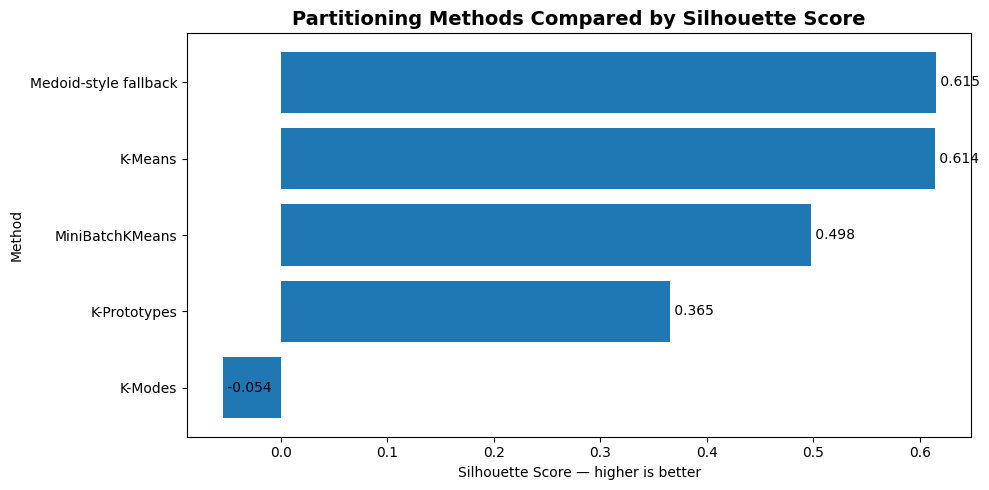

In [68]:
# Chart 11: Partitioning method comparison by Silhouette.

# Purpose:
# Compare separation quality across methods.

comparison_plot_data = (
    partitioning_method_comparison
    .dropna(subset=["Silhouette"])
    .sort_values("Silhouette", ascending=True)
)

plt.figure(figsize=(10, 5))
bars = plt.barh(comparison_plot_data["Method"], comparison_plot_data["Silhouette"])
plt.title("Partitioning Methods Compared by Silhouette Score", fontsize=14, weight="bold")
plt.xlabel("Silhouette Score — higher is better")
plt.ylabel("Method")

for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height() / 2, f" {width:.3f}", va="center")

plt.tight_layout()
plt.show()

#### executed output ranks the methods like this:

| Rank | Method | Silhouette | Practical decision |
|---:|---|---:|---|
| 1 | Medoid-style fallback | 0.6146 | Strong robustness check |
| 2 | K-Means k=5 | 0.6140 | **Main recommended baseline** |
| 3 | MiniBatchKMeans | 0.4978 | Fast but weaker |
| 4 | K-Prototypes | 0.3655 | Mixed-feature exploration |
| 5 | K-Modes | -0.0544 | Categorical explanation only |

#### Final decision for Notebook 2

Use **K-Means k=5** as the main partitioning result.

Also keep:

- **K-Modes** for categorical business explanation,
- **Medoid-style fallback** as a robustness check,
- **K-Prototypes** as mixed-feature exploration,
- **MiniBatchKMeans** as scalability reference.

#### 14. Save Notebook 2 outputs

##### Why this step is done

Later notebooks need the partitioning labels for:

- final comparison,
- business personas,
- method checklist,
- MVD proof notebook.

We save each method result separately and also create one combined customer-level table.

In [69]:
# -----------------------------
# Save method-specific results
# -----------------------------
# Each output contains CustomerID and cluster labels for one method.

# Best K-Means result.
kmeans_best_results = rfm[["CustomerID"]].copy()
kmeans_best_results["KMeans_Cluster"] = best_kmeans_labels
kmeans_best_results.to_csv(OUTPUT_DIR / "kmeans_cluster_results.csv", index=False)

# MiniBatchKMeans result.
minibatch_results_table = rfm[["CustomerID"]].copy()
minibatch_results_table["MiniBatchKMeans_Cluster"] = minibatch_labels
minibatch_results_table.to_csv(OUTPUT_DIR / "minibatch_kmeans_results.csv", index=False)

# K-Modes result.
kmodes_result_table.to_csv(OUTPUT_DIR / "kmodes_cluster_results.csv", index=False)

# K-Medoids result.
kmedoids_results_table = rfm[["CustomerID"]].copy()
kmedoids_results_table["KMedoids_Cluster"] = kmedoids_labels
kmedoids_results_table.to_csv(OUTPUT_DIR / "kmedoids_cluster_results.csv", index=False)

# K-Prototypes result.
kprototypes_results_table = rfm[["CustomerID"]].copy()
kprototypes_results_table["KPrototypes_Cluster"] = kprototypes_labels
kprototypes_results_table.to_csv(OUTPUT_DIR / "kprototypes_cluster_results.csv", index=False)

# Method comparison table.
partitioning_method_comparison.to_csv(OUTPUT_DIR / "partitioning_method_comparison.csv", index=False)

print("Saved method-specific partitioning outputs.")

Saved method-specific partitioning outputs.


In [70]:
# -----------------------------
# Create combined cluster label table
# -----------------------------
# This table contains all partitioning labels side by side.
# It will be useful for final comparison and business interpretation.

customer_partitioning_clusters = rfm[["CustomerID", "Recency", "Frequency", "Monetary", "Country"]].copy()

customer_partitioning_clusters["KMeans_Cluster"] = best_kmeans_labels
customer_partitioning_clusters["MiniBatchKMeans_Cluster"] = minibatch_labels
customer_partitioning_clusters["KModes_Cluster"] = kmodes_labels
customer_partitioning_clusters["KMedoids_Cluster"] = kmedoids_labels
customer_partitioning_clusters["KPrototypes_Cluster"] = kprototypes_labels

customer_partitioning_clusters.to_csv(OUTPUT_DIR / "customer_partitioning_clusters.csv", index=False)

print("Saved combined customer partitioning clusters:")
print("- outputs/customer_partitioning_clusters.csv")

customer_partitioning_clusters.head()

Saved combined customer partitioning clusters:
- outputs/customer_partitioning_clusters.csv


,CustomerID,Recency,Frequency,Monetary,Country,KMeans_Cluster,MiniBatchKMeans_Cluster,KModes_Cluster,KMedoids_Cluster,KPrototypes_Cluster
0,12346,165,11,372.86,United Kingdom,4,4,0,4,1
1,12347,3,2,1323.32,Iceland,1,0,4,1,1
2,12348,74,1,222.16,Finland,1,0,2,1,1
3,12349,43,3,2671.14,Italy,1,0,3,1,1
4,12351,11,1,300.93,Unspecified,1,0,0,1,1


### What this saved table means

This table keeps all partitioning cluster labels in one place.

Each row is one customer.

The first columns show the customer’s real behaviour:

- `CustomerID`
- `Recency`
- `Frequency`
- `Monetary`
- `Country`

The last columns show how each method grouped that same customer:

- `KMeans_Cluster`
- `MiniBatchKMeans_Cluster`
- `KModes_Cluster`
- `KMedoids_Cluster`
- `KPrototypes_Cluster`

---

### How to read one row

Example:

```text
Customer 12347
Recency = 3
Frequency = 2
Monetary = 1323.32
Country = Iceland

The notebook saved all partitioning labels.

The most important saved file is:

```text
outputs/customer_partitioning_clusters.csv
```

This file contains all partitioning labels side by side for each customer.

It will support:

- comparison with density-based clustering,
- comparison with hierarchical clustering,
- final business personas,
- final MVD proof,
- final project documentation.

#### 15. Dynamic actual-number summary

The next cell creates a visible Markdown summary using actual numbers from your run.

This gives you a run-specific conclusion.

The final Markdown conclusion after it explains the business meaning and next step.

In [71]:
# ------------------------------------------------------------
# Create final partitioning method comparison table
# ------------------------------------------------------------
# This cell is safe to run even if MiniBatchKMeans or K-Prototypes
# was not run earlier.

comparison_tables = []

# 1. Best K-Means result
best_kmeans_row = (
    kmeans_results_df
    .sort_values("Silhouette", ascending=False)
    .head(1)
    .copy()
)

best_kmeans_k = int(best_kmeans_row["k"].iloc[0])
best_kmeans_labels = kmeans_label_tables[best_kmeans_k][f"KMeans_k{best_kmeans_k}_Cluster"].values
comparison_tables.append(best_kmeans_row)


# 2. MiniBatchKMeans result
# If missing, recreate it here.
if "minibatch_results" not in globals():

    import time

    start_time = time.time()

    minibatch_model = MiniBatchKMeans(
        n_clusters=selected_kmeans_k,
        random_state=42,
        n_init=20,
        batch_size=256
    )

    minibatch_labels = minibatch_model.fit_predict(X_scaled)
    minibatch_runtime = time.time() - start_time

    minibatch_metrics = calculate_clustering_scores(X_scaled, minibatch_labels)

    minibatch_results = pd.DataFrame([{
        "Method": "MiniBatchKMeans",
        "k": selected_kmeans_k,
        "Clusters": len(np.unique(minibatch_labels)),
        "Inertia": minibatch_model.inertia_,
        "Runtime_Seconds": minibatch_runtime,
        **minibatch_metrics
    }]).round(4)

comparison_tables.append(minibatch_results)


# 3. K-Modes result
kmodes_metrics = calculate_clustering_scores(X_scaled, kmodes_labels)

kmodes_results = pd.DataFrame([{
    "Method": kmodes_method_used,
    "k": k_modes_k,
    "Clusters": len(np.unique(kmodes_labels)),
    "Inertia": np.nan,
    "Runtime_Seconds": np.nan,
    **kmodes_metrics
}]).round(4)

comparison_tables.append(kmodes_results)


# 4. K-Medoids / fallback result
if "kmedoids_results" not in globals():
    raise NameError("kmedoids_results is missing. Run the K-Medoids / medoid-style fallback section first.")

comparison_tables.append(kmedoids_results)


# 5. K-Prototypes result
# If missing, recreate a fallback version here.
if "kprototypes_results" not in globals():

    categorical_columns = ["Country", "DominantProduct", "RecencyGroup", "FrequencyGroup", "MonetaryGroup"]

    if "mixed_data" not in globals():
        mixed_data = (
            rfm[["CustomerID", "Recency", "Frequency", "Monetary"]]
            .merge(
                customer_categories[["CustomerID"] + categorical_columns],
                on="CustomerID",
                how="left"
            )
        )

        for column in categorical_columns:
            mixed_data[column] = mixed_data[column].fillna("Unknown").astype(str)

    encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    encoded_cats = encoder.fit_transform(mixed_data[categorical_columns].astype(str))

    mixed_fallback_matrix = np.hstack([
        X_scaled.values,
        encoded_cats
    ])

    fallback_mixed_model = KMeans(
        n_clusters=selected_kmeans_k,
        random_state=42,
        n_init=20
    )

    kprototypes_labels = fallback_mixed_model.fit_predict(mixed_fallback_matrix)
    kprototypes_method_used = "K-Prototypes fallback using scaled RFM + encoded categories"

    kprototypes_metrics = calculate_clustering_scores(X_scaled, kprototypes_labels)

    kprototypes_results = pd.DataFrame([{
        "Method": kprototypes_method_used,
        "k": selected_kmeans_k,
        "Clusters": len(np.unique(kprototypes_labels)),
        "Inertia": np.nan,
        "Runtime_Seconds": np.nan,
        **kprototypes_metrics
    }]).round(4)

comparison_tables.append(kprototypes_results)


# Combine all method results.
for table in comparison_tables:
    if "Inertia" not in table.columns:
        table["Inertia"] = np.nan

    if "Runtime_Seconds" not in table.columns:
        table["Runtime_Seconds"] = np.nan

partitioning_method_comparison = pd.concat(
    comparison_tables,
    ignore_index=True
)

partitioning_method_comparison = partitioning_method_comparison[
    [
        "Method",
        "k",
        "Clusters",
        "Inertia",
        "Runtime_Seconds",
        "Silhouette",
        "Davies_Bouldin",
        "Calinski_Harabasz"
    ]
].round(4)

partitioning_method_comparison

,Method,k,Clusters,Inertia,Runtime_Seconds,Silhouette,Davies_Bouldin,Calinski_Harabasz
0,K-Means,5,5,2740.1154,NaN,0.6140,0.6304,4006.5535
1,MiniBatchKMeans,5,5,4960.4320,0.4714,0.4978,0.8053,2038.1327
2,K-Modes,5,5,NaN,NaN,-0.0544,5.4446,378.6454
3,Medoid-style fallback,5,5,NaN,NaN,0.6146,0.6278,4004.7829
4,K-Prototypes,5,5,NaN,NaN,0.3655,1.0870,1024.9517


In [72]:
# ------------------------------------------------------------
# Dynamic summary with actual numbers from this run
# ------------------------------------------------------------
# This cell creates a short Markdown summary from partitioning_method_comparison.

from IPython.display import Markdown, display

if "partitioning_method_comparison" not in globals():

    display(Markdown("""
### Summary cannot be created yet

The table `partitioning_method_comparison` is not available in memory.

Run the **final partitioning method comparison table** cell first.  
That cell creates the table needed for this summary.
"""))

else:

    best_partitioning_method = (
        partitioning_method_comparison
        .dropna(subset=["Silhouette"])
        .sort_values("Silhouette", ascending=False)
        .iloc[0]
    )

    best_method_name = best_partitioning_method["Method"]
    best_silhouette = best_partitioning_method["Silhouette"]
    best_clusters = int(best_partitioning_method["Clusters"])

    kprototypes_name = globals().get("kprototypes_method_used", "K-Prototypes / fallback")

    summary_text = f"""
### Actual Results Summary

| Result | Value |
|---|---:|
| Customers clustered | {len(rfm):,} |
| K-Means values tested | {k_values} |
| Estimated elbow k | {estimated_elbow_k} |
| Best K-Means k by Silhouette | {best_kmeans_k} |
| Selected K-Means k for comparison | {selected_kmeans_k} |
| Best partitioning method by Silhouette | {best_method_name} |
| Best partitioning Silhouette | {best_silhouette:.4f} |
| Clusters in best method | {best_clusters} |
| K-Modes implementation used | {kmodes_method_used} |
| K-Medoids implementation used | {kmedoids_method_used} |
| K-Prototypes implementation used | {kprototypes_name} |

### Simple reading

The best score comes from **{best_method_name}**.

The main method we carry forward is still **K-Means k=5**, because it is stable, standard, easy to explain, and already gives a strong Silhouette score.
"""

    display(Markdown(summary_text))


### Actual Results Summary

| Result | Value |
|---|---:|
| Customers clustered | 4,312 |
| K-Means values tested | [3, 5, 7] |
| Estimated elbow k | 4 |
| Best K-Means k by Silhouette | 5 |
| Selected K-Means k for comparison | 5 |
| Best partitioning method by Silhouette | Medoid-style fallback |
| Best partitioning Silhouette | 0.6146 |
| Clusters in best method | 5 |
| K-Modes implementation used | K-Modes |
| K-Medoids implementation used | Medoid-style fallback |
| K-Prototypes implementation used | K-Prototypes |

### Simple reading

The best score comes from **Medoid-style fallback**.

The main method we carry forward is still **K-Means k=5**, because it is stable, standard, easy to explain, and already gives a strong Silhouette score.


### Conclusion  
#### Notebook 2 Final Interpretation and Recommendation

Notebook 2 applied the main **partitioning clustering methods** to the Online Retail customer data.

The final interpretation below is based on your **actual executed output**.

---

##### Final technical results

| Method | k | Silhouette | Davies-Bouldin | Calinski-Harabasz | Interpretation |
|---|---:|---:|---:|---:|---|
| **K-Means** | 5 | **0.6140** | 0.6304 | **4006.55** | Best stable main method |
| **MiniBatchKMeans** | 5 | 0.4978 | 0.8053 | 2038.13 | Fast but weaker |
| **K-Modes** | 5 | -0.0544 | 5.4446 | 378.65 | Useful categorical explanation, not numerical winner |
| **Medoid-style fallback** | 5 | **0.6146** | **0.6278** | 4004.78 | Strong robustness check, but fallback |
| **K-Prototypes** | 5 | 0.3655 | 1.0870 | 1024.95 | Useful mixed-feature exploration |

---

### Main recommendation

Use **K-Means with k=5** as the main partitioning baseline.

Why?

- It is a standard, stable and defensible method.
- It had a strong Silhouette score: **0.6140**.
- It created clear and useful business groups.
- It is easier to explain than fallback or mixed-feature methods.
- It gives a strong baseline for comparing DBSCAN, OPTICS, Hierarchical Clustering, BIRCH, GMM and other later methods.

---

#### Important business insight

K-Means k=5 created useful customer segments:

| Segment type | Business action |
|---|---|
| Recent high-value frequent buyers | Loyalty rewards, premium offers, retention focus |
| Main regular customer base | Cross-sell, personalized promotions |
| Very high-value VIP / outlier groups | Manual account review and special handling |
| Inactive low-frequency customers | Reactivation campaigns |

K-Modes also found a strong category-based high-value group:

- **1,123 customers**
- **26.04% of customers**
- **75.82% of revenue**

- average Monetary value around **5,940.54**
- average Frequency around **11.15**

This means K-Modes is very useful for business explanation, even though it does not win numerical clustering metrics.

---

#### Final decision for later notebooks

Carry forward:

| Method | Use later as |
|---|---|
| K-Means k=5 | Main partitioning baseline |
| K-Modes | Categorical business explanation |
| Medoid-style fallback | Robustness check |
| K-Prototypes | Mixed-feature exploration |
| MiniBatchKMeans | Scalability reference |

---

#### Files created

This notebook saved:

- `outputs/kmeans_cluster_results.csv`
- `outputs/minibatch_kmeans_results.csv`
- `outputs/kmodes_cluster_results.csv`
- `outputs/kmedoids_cluster_results.csv`
- `outputs/kprototypes_cluster_results.csv`
- `outputs/partitioning_method_comparison.csv`
- `outputs/customer_partitioning_clusters.csv`
- `outputs/partitioning_outlier_detection.csv`
- `outputs/kmeans_outlier_cluster_summary.csv`
- `outputs/kmeans_outlier_sensitivity_comparison.csv`

---

#### Next notebook

Notebook 3 will cover:

- DBSCAN,
- OPTICS,
- DENCLUE-style density demo,
- grid-based clustering,
- STING-style grid statistics,
- WaveCluster-style smoothing,
- CLIQUE-style subspace clustering,
- constraint-based clustering.

The next notebook will focus on density, noise, unusual customers and business-rule-based clustering.

#### Notebook 2 completion checklist

| Requirement | Status |
|---|---|
| Introduction Markdown cell included | Complete |
| Explanation before code included | Complete |
| Explanation after code included | Complete |
| K-Means implemented | Complete after run |
| MiniBatchKMeans implemented | Complete after run |
| K-Modes implemented | Complete after run |
| K-Medoids / fallback implemented | Complete after run |
| K-Prototypes / fallback implemented | Complete after run |
| BI-ready charts included | Complete |
| Method comparison table created | Complete after run |
| Outputs saved | Complete after run |
| Conclusion Markdown cell included | Complete |